# Payment gateway fraud detection

Take-home assignment notebook. It follows the assignment's task numbering (1 to 5), with a
summary in front (0) and limitations at the end (6).

All logic lives in the `app/` package (data generator, feature builder, model, evaluation,
validation, monitoring). This notebook imports those modules and reports what they produce:
the saved model is loaded and re-scored here, so every number below is computed in the cell
above it rather than typed in by hand.

In [1]:
import sys, json, time, logging, warnings
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "app").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
_t0 = time.time()

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.metrics import precision_recall_curve

from app.utils import config
from app.controllers.features import builder
from app.controllers.features.builder import build_features, load_transactions, window_mask
from app.controllers.training import model as model_mod
from app.controllers.training.trainer import split_masks
from app.controllers.evaluation import metrics as ev
from app.controllers.validation import schema
from app.controllers.validation.schema import validate
from app.controllers.monitoring import drift
from app.controllers.monitoring import report as monitoring

logging.getLogger("fraud").setLevel(logging.WARNING)   # keep the app's JSON logs out of the notebook
pd.set_option("display.max_columns", 40, "display.width", 200, "display.max_colwidth", None)

# One colour per role, used the same way in every chart.
C_MAIN, C_ALT, C_INK, C_MUTED, C_GRID = "#2a78d6", "#eb6834", "#52514e", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "figure.dpi": 110, "savefig.dpi": 150,
    "savefig.bbox": "tight", "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": C_INK, "xtick.color": C_INK, "ytick.color": C_INK,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": C_GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "legend.frameon": False, "lines.linewidth": 2,
})
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def say(text: str) -> None:
    """Markdown generated from code, so sentences that quote numbers never go stale."""
    display(Markdown(text))


def fmt(frame: pd.DataFrame, formats: dict) -> pd.DataFrame:
    """Copy of `frame` with the given columns rendered through format specs (display only)."""
    out = frame.copy()
    for col, spec in formats.items():
        if col in out:
            out[col] = out[col].map(lambda v, s=spec: "" if pd.isna(v) else format(v, s))
    return out


def savefig(name: str) -> None:
    plt.savefig(config.FIGURES_DIR / name)
    plt.show()

## 0. Summary and data statement

**Which data was used.** The provided file `data/fraud_detection_sample_transactions.csv`
has 12 rows. That is enough to learn the schema and not enough to train or test anything, so
a seeded simulator (`app/controllers/data_generation/generator.py`) produces transactions in
the same schema for January to September 2026. No public data set is used.

**What that means for the results.** The simulator plants four fraud patterns and several
kinds of drift, and the model is then asked to find them. Every metric in this notebook
therefore measures how well the simulated patterns are recovered. None of them is an estimate
of performance on real payment traffic. What does carry over to real data is the method: the
point-in-time features, the time-based split, the threshold policy, the validation checks and
the monitoring.

In [2]:
sample = pd.read_csv(config.SAMPLE_CSV)
display(sample)
say(f"The provided sample: **{len(sample)} rows**, {int(sample.fraud_label.sum())} labelled fraud "
    f"(fraud rate {sample.fraud_label.mean():.0%}). With {len(sample)} rows this rate says nothing about "
    f"real prevalence; the sample is used for the schema only.")

,request_id,request_time,service_type,device_id,merchant_id,merchant_state,merchant_city,merchant_type,mcc_code,mcc_title,issuer_bank,currency_code,amount,request_status,fraud_label
0,TXN100001,2026-01-03 09:14:02,upi,DEV1001,M100101,Maharashtra,Mumbai,low,5411,Grocery Stores,ICICI,INR,850.0,SUCCESS,0
1,TXN100002,2026-01-03 09:18:11,wallet,DEV1002,M100202,Delhi,New Delhi,high,6540,Prepaid/Stored Value Card Load,NOT_APPLICABLE,INR,78500.0,FAILED,1
2,TXN100003,2026-01-03 10:05:40,netbanking,DEV1003,M100303,Karnataka,Bengaluru,low,5311,Department Stores,HDFC,INR,2450.5,SUCCESS,0
3,TXN100004,2026-01-03 10:06:15,netbanking,DEV1003,M100303,Karnataka,Bengaluru,low,5311,Department Stores,HDFC,INR,2590.0,SUCCESS,0
4,TXN100005,2026-01-03 10:07:08,netbanking,DEV1003,M100303,Karnataka,Bengaluru,low,5311,Department Stores,HDFC,INR,74000.0,SUCCESS,1
5,TXN100006,2026-01-03 12:30:45,imps,DEV1004,M100404,Tamil Nadu,Chennai,low,8299,Educational Services,INDUSIND,INR,12000.0,SUCCESS,0
6,TXN100007,2026-01-03 23:48:12,wallet,DEV1005,M100505,Odisha,Bhubaneswar,high,7273,Dating and Escort Services,NOT_APPLICABLE,INR,43200.0,FAILED,1
7,TXN100008,2026-01-04 00:03:21,upi,DEV1006,M100606,Rajasthan,Jaipur,medium,5732,Electronic Stores,SBI,INR,39999.0,DECLINED,0
8,TXN100009,2026-01-04 08:12:09,upi,DEV1001,M100101,Maharashtra,Mumbai,low,5411,Grocery Stores,ICICI,INR,950.0,SUCCESS,0
9,TXN100010,2026-01-04 02:15:36,netbanking,DEV1007,M100707,Uttar Pradesh,Lucknow,high,6540,Prepaid/Stored Value Card Load,BOB,INR,92000.0,SUCCESS,1


The provided sample: **12 rows**, 4 labelled fraud (fraud rate 33%). With 12 rows this rate says nothing about real prevalence; the sample is used for the schema only.

In [3]:
df = load_transactions()
X = build_features(df)                       # point-in-time features for every row (section 2)
y = df[config.TARGET].to_numpy()
masks = split_masks(df)
champion = joblib.load(config.MODEL_PATH)
baseline = joblib.load(config.MODELS_DIR / "baseline_model.joblib")
score = champion.score(X)                    # calibrated fraud probability
score_base = baseline.score(X)
training_report = json.loads((config.REPORTS_DIR / "training_report.json").read_text())
model_card = json.loads(config.MODEL_CARD_PATH.read_text())

extra_cols = sorted(set(df.columns) - set(sample.columns))
assert set(sample.columns) <= set(df.columns)
say(f"Synthetic data: **{len(df):,} transactions**, {df.request_time.min():%d %b %Y} to "
    f"{df.request_time.max():%d %b %Y}, {df.device_id.nunique():,} devices, {df.merchant_id.nunique():,} "
    f"merchants, seed {config.SEED}. It has every column of the sample plus `{extra_cols[0]}`, the "
    f"simulator's ground truth about which planted pattern a row belongs to. That column is used only to "
    f"break results down by pattern and is never a model input.")

Synthetic data: **566,754 transactions**, 01 Jan 2026 to 30 Sep 2026, 29,844 devices, 1,500 merchants, seed 42. It has every column of the sample plus `fraud_pattern`, the simulator's ground truth about which planted pattern a row belongs to. That column is used only to break results down by pattern and is never a model input.

What the simulator contains (from the generator's docstring), so the reader knows what is
there to be found:

- genuine behaviour with hard negatives: legitimate big-ticket purchases, quick repeat
  purchases, retries after a failed payment, night-time users, genuine use of high-risk merchants;
- fraud pattern A, account takeover: bursts of large payments on an existing device;
- fraud pattern B, mule devices: brand-new devices used only for fraud, mostly at high-risk merchants;
- fraud pattern C, stealth: single, moderately unusual payments that look almost normal;
- fraud pattern D, a new UPI scam that only starts on 10 July (concept drift for section 5);
- live-period drift: amount inflation, a shift towards UPI, an August-September midnight sale,
  and a September data-quality incident (missing `issuer_bank`);
- label noise: some frauds are never reported and a few genuine payments are disputed.

The headline results, computed further down, are repeated here for convenience.

In [4]:
_te = masks["test"]
_m = ev.evaluate(y[_te], score[_te], champion.review_threshold)
_b = ev.evaluate(y[_te], score_base[_te], baseline.review_threshold)
_blk = ev.threshold_metrics(y[_te], score[_te], champion.block_threshold)
say(f"""
| | |
|---|---|
| Champion | `{training_report['champion']['name']}` (HistGradientBoosting), version {champion.version} |
| Baseline | `{training_report['baseline']['name']}` (Logistic Regression) |
| June hold-out, champion | PR-AUC {_m['pr_auc']:.3f}, ROC-AUC {_m['roc_auc']:.3f}; at the review threshold precision {_m['precision']:.3f}, recall {_m['recall']:.3f}, F1 {_m['f1']:.3f} |
| June hold-out, baseline | PR-AUC {_b['pr_auc']:.3f}, ROC-AUC {_b['roc_auc']:.3f}; precision {_b['precision']:.3f}, recall {_b['recall']:.3f}, F1 {_b['f1']:.3f} |
| Auto-decline band (champion) | precision {_blk['precision']:.3f}, recall {_blk['recall']:.3f}, {_blk['fp']} false declines in {_m['n']:,} payments |
| Live period | performance holds in July and falls sharply in August and September, when the new fraud pattern grows (section 5) |
""")


| | |
|---|---|
| Champion | `gbm | sqrt weights | lr=0.05 trees=300` (HistGradientBoosting), version 1.0.0 |
| Baseline | `logreg | no weighting` (Logistic Regression) |
| June hold-out, champion | PR-AUC 0.752, ROC-AUC 0.980; at the review threshold precision 0.533, recall 0.762, F1 0.627 |
| June hold-out, baseline | PR-AUC 0.643, ROC-AUC 0.960; precision 0.581, recall 0.637, F1 0.608 |
| Auto-decline band (champion) | precision 0.959, recall 0.482, 11 false declines in 47,584 payments |
| Live period | performance holds in July and falls sharply in August and September, when the new fraud pattern grows (section 5) |


## 1. Understand the data

The EDA uses the development period only (before the live period starts), so nothing about
July to September influences any modelling decision.

In [5]:
dev = df[df.request_time < pd.Timestamp(config.LIVE_START)]
Xdev, ydev = X.loc[dev.index], dev[config.TARGET]
base_rate = ydev.mean()

overview = pd.DataFrame({
    "dtype": dev.dtypes.astype(str),
    "distinct": dev.nunique(),
    "missing": dev.isna().mean().map("{:.2%}".format),
    "example": dev.iloc[0].astype(str),
})
display(overview)
say(f"Development period: {len(dev):,} transactions from {dev.request_time.min():%d %b} to "
    f"{dev.request_time.max():%d %b %Y}. Missing values occur only in `issuer_bank`, `merchant_state`, "
    f"`merchant_city` and `mcc_title`. `currency_code` is constant. Wallet payments carry "
    f"`issuer_bank = NOT_APPLICABLE`, which is a real category, not a missing value.")

,dtype,distinct,missing,example
request_id,object,335372,0.00%,TXN1000000
request_time,datetime64[ns],330488,0.00%,2026-01-01 00:03:42
service_type,object,4,0.00%,upi
device_id,object,26837,0.00%,DEV0030399
merchant_id,object,1500,0.00%,M100391
merchant_state,object,15,0.50%,Karnataka
merchant_city,object,18,0.50%,Bengaluru
merchant_type,object,3,0.00%,medium
mcc_code,Int64,18,0.00%,5411
mcc_title,object,18,0.48%,Grocery Stores


Development period: 335,372 transactions from 01 Jan to 30 Jun 2026. Missing values occur only in `issuer_bank`, `merchant_state`, `merchant_city` and `mcc_title`. `currency_code` is constant. Wallet payments carry `issuer_bank = NOT_APPLICABLE`, which is a real category, not a missing value.

### 1.1 Fraud rate

In [6]:
monthly = dev.groupby(dev.request_time.dt.strftime("%Y-%m"))[config.TARGET].agg(
    transactions="size", frauds="sum", fraud_rate="mean")
display(fmt(monthly, {"transactions": ",", "frauds": ",", "fraud_rate": ".2%"}))
say(f"**Fraud rate in the development period: {base_rate:.2%}** ({int(ydev.sum()):,} frauds in {len(dev):,} "
    f"transactions), between {monthly.fraud_rate.min():.2%} and {monthly.fraud_rate.max():.2%} per month. "
    f"By value, fraud is {dev.loc[ydev == 1, 'amount'].sum() / dev.amount.sum():.1%} of the amount processed, "
    f"because fraudulent payments are much larger than genuine ones. Live-month rates are reported in "
    f"section 5, where they belong.")

,transactions,frauds,fraud_rate
request_time,,,
2026-01,"52,192",600,1.15%
2026-02,"48,620",606,1.25%
2026-03,"55,776",657,1.18%
2026-04,"56,137",593,1.06%
2026-05,"60,797",619,1.02%
2026-06,"61,850",695,1.12%


**Fraud rate in the development period: 1.12%** (3,770 frauds in 335,372 transactions), between 1.02% and 1.25% per month. By value, fraud is 4.7% of the amount processed, because fraudulent payments are much larger than genuine ones. Live-month rates are reported in section 5, where they belong.

### 1.2 Fraud signals

Each signal the assignment lists is checked below. `lift` is the group's fraud rate divided by
the overall rate. The behavioural columns (`dev_*`) come from the feature builder and only use
transactions that happened earlier.

In [7]:
def rate_table(key, name: str, order=None) -> pd.DataFrame:
    t = pd.DataFrame({name: np.asarray(key), "y": ydev.to_numpy()}).groupby(name, observed=True)["y"].agg(
        transactions="size", frauds="sum", fraud_rate="mean")
    t["lift"] = t.fraud_rate / base_rate
    return t.loc[order] if order is not None else t


def show_rates(t: pd.DataFrame) -> None:
    display(fmt(t, {"transactions": ",", "frauds": ",", "fraud_rate": ".2%", "lift": ".1f"}))


amount_band = pd.cut(dev.amount, [0, 500, 2000, 5000, 20000, 50000, np.inf],
                     labels=["<500", "500-2k", "2k-5k", "5k-20k", "20k-50k", ">50k"])
t_amount = rate_table(amount_band, "amount (INR)", list(amount_band.cat.categories))
ratio_band = pd.cut(Xdev.dev_amt_ratio, [0, 1, 2, 5, 10, np.inf],
                    labels=["<=1x", "1-2x", "2-5x", "5-10x", ">10x"]).astype(object).fillna("no 30-day history")
t_ratio = rate_table(ratio_band, "amount vs device's 30-day average",
                     ["<=1x", "1-2x", "2-5x", "5-10x", ">10x", "no 30-day history"])
show_rates(t_amount)
show_rates(t_ratio)
say(f"**Unusual amount.** Fraud rate rises from {t_amount.fraud_rate.iloc[0]:.2%} below INR 500 to "
    f"{t_amount.fraud_rate.iloc[-1]:.1%} above INR 50k. Relative to the device's own 30-day average the rate "
    f"rises from {t_ratio.fraud_rate['<=1x']:.2%} (at or below average) to {t_ratio.fraud_rate['5-10x']:.1%} "
    f"(5-10x). On its own this ratio is a weaker signal than the absolute amount, because genuine customers "
    f"also make occasional large purchases and a fraud burst raises the device's own average; it is kept "
    f"because it says something the absolute amount does not (large for this customer). A device with no "
    f"30-day history is not riskier by itself ({t_ratio.fraud_rate['no 30-day history']:.2%}): most new "
    f"devices are new genuine customers.")

,transactions,frauds,fraud_rate,lift
amount (INR),,,,
<500,"68,315",145,0.21%,0.2
500-2k,"140,615",296,0.21%,0.2
2k-5k,"62,878",672,1.07%,1.0
5k-20k,"46,933","1,521",3.24%,2.9
20k-50k,"13,064",767,5.87%,5.2
>50k,"3,567",369,10.34%,9.2


,transactions,frauds,fraud_rate,lift
amount vs device's 30-day average,,,,
<=1x,"174,743","1,166",0.67%,0.6
1-2x,"50,109",696,1.39%,1.2
2-5x,"35,019",798,2.28%,2.0
5-10x,"12,171",390,3.20%,2.9
>10x,"11,777",341,2.90%,2.6
no 30-day history,"51,553",379,0.74%,0.7


**Unusual amount.** Fraud rate rises from 0.21% below INR 500 to 10.3% above INR 50k. Relative to the device's own 30-day average the rate rises from 0.67% (at or below average) to 3.2% (5-10x). On its own this ratio is a weaker signal than the absolute amount, because genuine customers also make occasional large purchases and a fraud burst raises the device's own average; it is kept because it says something the absolute amount does not (large for this customer). A device with no 30-day history is not riskier by itself (0.74%): most new devices are new genuine customers.

In [8]:
t_mtype = rate_table(dev.merchant_type, "merchant_type", ["low", "medium", "high"])
t_mcc = rate_table(dev.mcc_code.astype(str) + " " + dev.mcc_title.fillna("(title missing)"), "mcc")
t_mcc = t_mcc[~t_mcc.index.str.contains("title missing")].sort_values("fraud_rate", ascending=False)
show_rates(t_mtype)
show_rates(t_mcc)
say(f"**High-risk merchant type / MCC.** High-risk merchants have a fraud rate of "
    f"{t_mtype.fraud_rate['high']:.1%} against {t_mtype.fraud_rate['low']:.2%} for low-risk ones "
    f"({t_mtype.fraud_rate['high'] / t_mtype.fraud_rate['low']:.0f}x). The MCC table shows the same from "
    f"the category side: `{t_mcc.index[0]}` is the riskiest category and `{t_mcc.index[-1]}` the safest. "
    f"Even in the riskiest category most payments are genuine, so MCC alone cannot be a decline rule.")

,transactions,frauds,fraud_rate,lift
merchant_type,,,,
low,"209,544","1,162",0.55%,0.5
medium,"91,965","1,028",1.12%,1.0
high,"33,863","1,580",4.67%,4.2


,transactions,frauds,fraud_rate,lift
mcc,,,,
6540 Prepaid/Stored Value Card Load,"5,482",330,6.02%,5.4
6051 Quasi Cash and Crypto,"5,946",254,4.27%,3.8
4829 Money Transfer,"4,569",167,3.66%,3.3
7995 Betting and Gambling,"6,048",196,3.24%,2.9
7273 Dating and Escort Services,"1,244",29,2.33%,2.1
4900 Utilities,"20,681",296,1.43%,1.3
5999 Miscellaneous Retail Stores,"25,470",310,1.22%,1.1
4814 Telecommunication Services,"27,763",325,1.17%,1.0
5912 Drug Stores and Pharmacies,"24,192",268,1.11%,1.0


**High-risk merchant type / MCC.** High-risk merchants have a fraud rate of 4.7% against 0.55% for low-risk ones (8x). The MCC table shows the same from the category side: `6540 Prepaid/Stored Value Card Load` is the riskiest category and `8299 Educational Services` the safest. Even in the riskiest category most payments are genuine, so MCC alone cannot be a decline rule.

In [9]:
night = np.where(Xdev.is_night == 1, "night (23:00-05:59)", "day")
t_night = rate_table(night, "time of day")
t_hour = rate_table(dev.request_time.dt.hour, "hour")
velocity = pd.cut(Xdev.dev_cnt_1h, [-1, 0, 1, 2, np.inf], labels=["0", "1", "2", "3+"])
t_vel = rate_table(velocity, "device payments in the previous hour")
t_new = rate_table(np.where(Xdev.dev_cnt_30d == 0, "no payments in previous 30 days", "has history"), "device history")
show_rates(t_night)
show_rates(t_vel)
show_rates(t_new)
say(f"**Late-night transactions.** Night-time payments are fraud {t_night.fraud_rate.iloc[1]:.2%} of the time "
    f"against {t_night.fraud_rate.iloc[0]:.2%} during the day (the hourly profile is in the chart below).\n\n"
    f"**Repeated device activity.** With no other payment from the device in the previous hour the fraud rate "
    f"is {t_vel.fraud_rate['0']:.2%}; with three or more it is {t_vel.fraud_rate['3+']:.1%}. A single earlier "
    f"payment is a weaker signal ({t_vel.fraud_rate['1']:.1%}) because genuine customers also repeat and "
    f"retry. Having no history at all is, again, not a risk signal alone "
    f"({t_new.fraud_rate['no payments in previous 30 days']:.2%}); it only matters in combination with "
    f"amount, merchant tier and time, which is an argument for a tree model.")

,transactions,frauds,fraud_rate,lift
time of day,,,,
day,"316,447","2,494",0.79%,0.7
night (23:00-05:59),"18,925","1,276",6.74%,6.0


,transactions,frauds,fraud_rate,lift
device payments in the previous hour,,,,
0,"295,607","2,101",0.71%,0.6
1,"32,198",905,2.81%,2.5
2,"6,892",488,7.08%,6.3
3+,675,276,40.89%,36.4


,transactions,frauds,fraud_rate,lift
device history,,,,
has history,"283,819","3,391",1.19%,1.1
no payments in previous 30 days,"51,553",379,0.74%,0.7


**Late-night transactions.** Night-time payments are fraud 6.74% of the time against 0.79% during the day (the hourly profile is in the chart below).

**Repeated device activity.** With no other payment from the device in the previous hour the fraud rate is 0.71%; with three or more it is 40.9%. A single earlier payment is a weaker signal (2.8%) because genuine customers also repeat and retry. Having no history at all is, again, not a risk signal alone (0.74%); it only matters in combination with amount, merchant tier and time, which is an argument for a tree model.

In [10]:
t_service = rate_table(dev.service_type, "service_type").sort_values("fraud_rate")
t_status = rate_table(dev.request_status, "request_status", ["SUCCESS", "FAILED", "DECLINED"])
prior_fail = np.where(Xdev.dev_fail_cnt_1h > 0, "1+ failed/declined", "none")
t_prior = rate_table(prior_fail, "device's EARLIER payments in the previous hour", ["none", "1+ failed/declined"])
show_rates(t_service)
show_rates(t_status)
show_rates(t_prior)
say(f"**Payment method.** `{t_service.index[-1]}` has the highest fraud rate ({t_service.fraud_rate.iloc[-1]:.2%}) "
    f"and `{t_service.index[0]}` the lowest ({t_service.fraud_rate.iloc[0]:.2%}).\n\n"
    f"**Transaction status.** Failed and declined payments are fraud {t_status.fraud_rate['FAILED']:.1%} and "
    f"{t_status.fraud_rate['DECLINED']:.1%} of the time against {t_status.fraud_rate['SUCCESS']:.2%} for "
    f"successful ones. This is a real signal, but the status of a payment is its outcome and is not known "
    f"when the fraud decision is made, so the model never sees it (section 1.3). What is known is the status "
    f"of the device's earlier payments: after a failed or declined payment in the previous hour the fraud "
    f"rate is {t_prior.fraud_rate['1+ failed/declined']:.1%}. It is a weak signal on its own because genuine "
    f"retries after a failure are common.")

,transactions,frauds,fraud_rate,lift
service_type,,,,
upi,"182,996","1,191",0.65%,0.6
imps,"32,805",390,1.19%,1.1
netbanking,"67,828","1,013",1.49%,1.3
wallet,"51,743","1,176",2.27%,2.0


,transactions,frauds,fraud_rate,lift
request_status,,,,
SUCCESS,"298,736","2,415",0.81%,0.7
FAILED,"25,371",861,3.39%,3.0
DECLINED,"11,265",494,4.39%,3.9


,transactions,frauds,fraud_rate,lift
device's EARLIER payments in the previous hour,,,,
none,"319,545","2,852",0.89%,0.8
1+ failed/declined,"15,827",918,5.80%,5.2


**Payment method.** `wallet` has the highest fraud rate (2.27%) and `upi` the lowest (0.65%).

**Transaction status.** Failed and declined payments are fraud 3.4% and 4.4% of the time against 0.81% for successful ones. This is a real signal, but the status of a payment is its outcome and is not known when the fraud decision is made, so the model never sees it (section 1.3). What is known is the status of the device's earlier payments: after a failed or declined payment in the previous hour the fraud rate is 5.8%. It is a weak signal on its own because genuine retries after a failure are common.

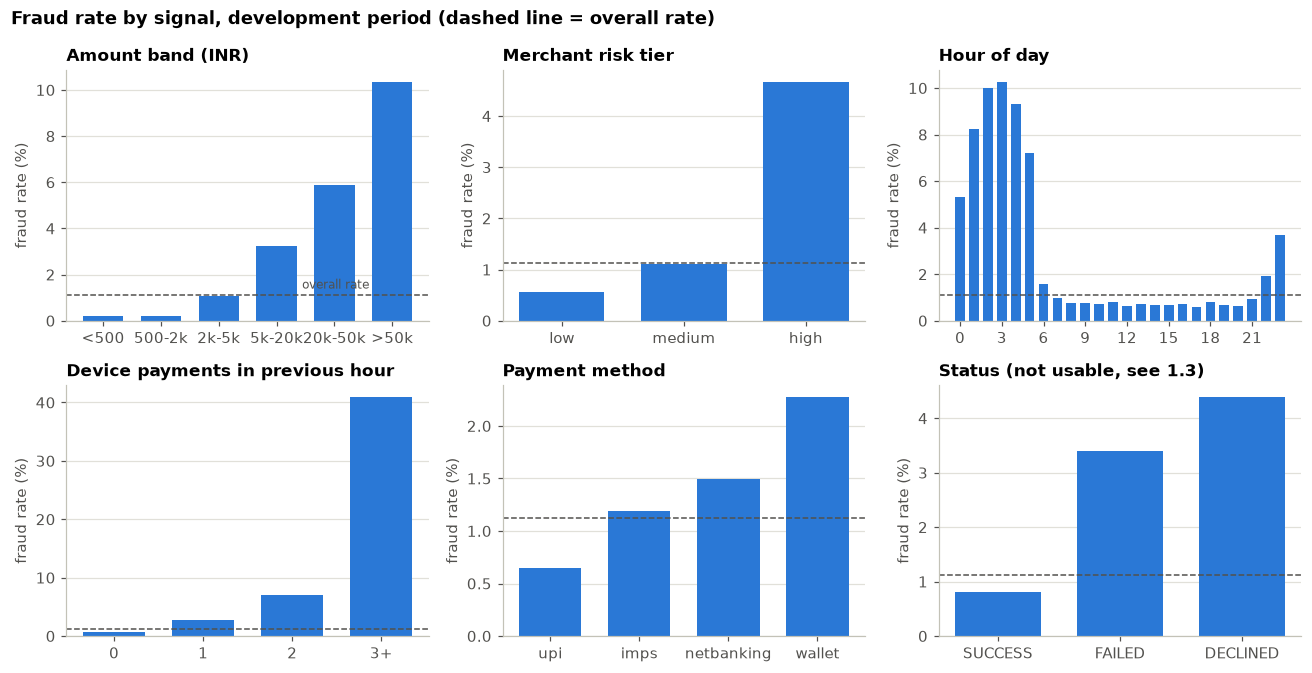

In [11]:
panels = [
    (t_amount, "Amount band (INR)"), (t_mtype, "Merchant risk tier"), (t_hour, "Hour of day"),
    (t_vel, "Device payments in previous hour"), (t_service, "Payment method"), (t_status, "Status (not usable, see 1.3)"),
]
fig, axes = plt.subplots(2, 3, figsize=(12, 6.2))
for ax, (t, title) in zip(axes.ravel(), panels):
    ax.bar([str(i) for i in t.index], t.fraud_rate * 100, color=C_MAIN, width=0.7)
    ax.axhline(base_rate * 100, color=C_INK, lw=1, ls="--")
    ax.set_title(title)
    ax.set_ylabel("fraud rate (%)")
    if len(t) > 12:
        ax.set_xticks(range(0, 24, 3))
axes[0, 0].annotate("overall rate", (len(t_amount) - 1.4, base_rate * 100), xytext=(0, 4),
                    textcoords="offset points", ha="right", fontsize=8, color=C_INK)
fig.suptitle("Fraud rate by signal, development period (dashed line = overall rate)", x=0.01, ha="left",
             fontweight="bold")
fig.tight_layout()
savefig("eda_fraud_signals.png")

The chart puts six signals side by side, each on its own scale. Device velocity, night-time
hours, high amounts and the high-risk merchant tier are the strongest single signals; payment
method is weaker; status is informative but unavailable at decision time.

### 1.3 Fields that are not used directly, and what is derived from them

In [12]:
fields = pd.DataFrame([
    ("request_id", "unique ID", "One value per row; no signal, would only be memorised.",
     "Nothing. Used as the row key and for duplicate checks."),
    ("device_id", "identifier, PII-like", "Identifies a customer device. High cardinality, so a model would memorise "
     "individual devices and fail on new ones; also personal data.",
     "Velocity (payments in 10 min / 1 h / 24 h / 7 d), amount spent in 1 h / 24 h, time since last payment, "
     "device age, amount vs the device's own 30-day history, new merchant or payment method for the device, "
     "earlier failed payments."),
    ("merchant_id", "identifier", "High cardinality; memorising merchants does not generalise to new ones.",
     "Merchant velocity, amount vs the merchant's usual ticket size, merchant fraud rate over labels that "
     "have matured (older than the label delay)."),
    ("merchant_city", "location", "Mostly redundant with merchant_state, at higher cardinality.",
     "merchant_state is used instead."),
    ("mcc_title", "duplicate", "Text version of mcc_code.", "mcc_code is used instead."),
    ("currency_code", "constant", "Single value (INR).", "Nothing. The validator checks it stays INR."),
    ("request_status", "LEAKAGE", "Outcome of the current payment; not known when the fraud decision is made. "
     "It may also be caused by the fraud controls themselves.",
     "Count of the device's EARLIER failed/declined payments in the previous 1 h and 24 h."),
    ("fraud_label", "target", "The label. It arrives late (chargebacks, disputes).",
     "Merchant fraud rate using only labels older than the label delay."),
    ("fraud_pattern", "simulator ground truth", "Exists only because the data is synthetic.",
     "Never a feature. Used only to break recall down by pattern."),
], columns=["field", "issue", "why not used directly", "derived features"])
display(fields.set_index("field"))
unused = [c for c in df.columns if c not in builder.FEATURES and c not in ("amount", "request_time")]
say(f"Columns of the raw data that are not model inputs: `{'`, `'.join(unused)}`. `amount` and "
    f"`request_time` enter only through derived features (log amount, hour, day of week and so on). "
    f"The model's categorical inputs are `{'`, `'.join(builder.CATEGORICAL)}`.")

,issue,why not used directly,derived features
field,,,
request_id,unique ID,"One value per row; no signal, would only be memorised.",Nothing. Used as the row key and for duplicate checks.
device_id,"identifier, PII-like","Identifies a customer device. High cardinality, so a model would memorise individual devices and fail on new ones; also personal data.","Velocity (payments in 10 min / 1 h / 24 h / 7 d), amount spent in 1 h / 24 h, time since last payment, device age, amount vs the device's own 30-day history, new merchant or payment method for the device, earlier failed payments."
merchant_id,identifier,High cardinality; memorising merchants does not generalise to new ones.,"Merchant velocity, amount vs the merchant's usual ticket size, merchant fraud rate over labels that have matured (older than the label delay)."
merchant_city,location,"Mostly redundant with merchant_state, at higher cardinality.",merchant_state is used instead.
mcc_title,duplicate,Text version of mcc_code.,mcc_code is used instead.
currency_code,constant,Single value (INR).,Nothing. The validator checks it stays INR.
request_status,LEAKAGE,Outcome of the current payment; not known when the fraud decision is made. It may also be caused by the fraud controls themselves.,Count of the device's EARLIER failed/declined payments in the previous 1 h and 24 h.
fraud_label,target,"The label. It arrives late (chargebacks, disputes).",Merchant fraud rate using only labels older than the label delay.
fraud_pattern,simulator ground truth,Exists only because the data is synthetic.,Never a feature. Used only to break recall down by pattern.


Columns of the raw data that are not model inputs: `request_id`, `device_id`, `merchant_id`, `merchant_city`, `mcc_title`, `currency_code`, `request_status`, `fraud_label`, `fraud_pattern`. `amount` and `request_time` enter only through derived features (log amount, hour, day of week and so on). The model's categorical inputs are `service_type`, `merchant_type`, `mcc_code`, `issuer_bank`, `merchant_state`.

## 2. Build a model

### 2.1 Features

All features come from one function, `build_features`. For each transaction it uses only
transactions of the same device or merchant that happened strictly earlier, so the value
computed in training is the value that could have been computed when the payment was scored.

In [13]:
groups = {
    "amount and time": ["log_amount", "amount_is_round", "hour", "day_of_week", "is_night", "is_weekend",
                        "hour_sin", "hour_cos"],
    "device behaviour": [f for f in builder.NUMERIC if f.startswith("dev_")],
    "merchant behaviour": [f for f in builder.NUMERIC if f.startswith("mer_")],
    "categorical": builder.CATEGORICAL,
}
assert sorted(sum(groups.values(), [])) == sorted(builder.FEATURES)
display(pd.DataFrame({"n": {k: len(v) for k, v in groups.items()},
                      "features": {k: ", ".join(v) for k, v in groups.items()}}))
say(f"{len(builder.FEATURES)} features. Three design rules:\n\n"
    f"- **Point-in-time.** Windows are `[t - window, t)`, excluding the current payment.\n"
    f"- **Fixed {builder.LOOKBACK_DAYS}-day lookback** for history features instead of 'everything so far'. "
    f"Unbounded history grows with calendar time, so such features drift by construction and would need "
    f"unbounded storage in a feature store.\n"
    f"- **Label delay of {config.LABEL_DELAY_DAYS} days.** The only label-based feature, `mer_fraud_rate_lag`, "
    f"uses labels from `[t - {config.LABEL_DELAY_DAYS + builder.LOOKBACK_DAYS} d, t - {config.LABEL_DELAY_DAYS} d)` "
    f"because fraud labels arrive late. It is smoothed towards a {builder.PRIOR_FRAUD_RATE:.0%} prior so small "
    f"merchants do not get extreme rates.")

,n,features
amount and time,8,"log_amount, amount_is_round, hour, day_of_week, is_night, is_weekend, hour_sin, hour_cos"
device behaviour,16,"dev_cnt_10m, dev_cnt_1h, dev_cnt_24h, dev_cnt_7d, dev_amt_sum_1h, dev_amt_sum_24h, dev_secs_since_last, dev_cnt_30d, dev_age_days, dev_logamt_z, dev_amt_ratio, dev_new_merchant, dev_new_merchants_24h, dev_new_service, dev_fail_cnt_1h, dev_fail_cnt_24h"
merchant behaviour,4,"mer_cnt_1h, mer_cnt_30d, mer_logamt_z, mer_fraud_rate_lag"
categorical,5,"service_type, merchant_type, mcc_code, issuer_bank, merchant_state"


33 features. Three design rules:

- **Point-in-time.** Windows are `[t - window, t)`, excluding the current payment.
- **Fixed 30-day lookback** for history features instead of 'everything so far'. Unbounded history grows with calendar time, so such features drift by construction and would need unbounded storage in a feature store.
- **Label delay of 7 days.** The only label-based feature, `mer_fraud_rate_lag`, uses labels from `[t - 37 d, t - 7 d)` because fraud labels arrive late. It is smoothed towards a 1% prior so small merchants do not get extreme rates.

In [14]:
# One account-takeover burst, to show the features are point-in-time. (fraud_pattern is used
# here only to pick an example.)
_tr = df[masks["train"] & (df.fraud_pattern == "A_takeover").to_numpy()]
_burst = _tr.groupby([_tr.device_id, _tr.request_time.dt.date]).size().sort_values(ascending=False).index[0]
_rows = df[(df.device_id == _burst[0]) & (df.request_time.dt.date <= _burst[1])].tail(6)
_demo = _rows[["request_time", "amount", "request_status", "fraud_label"]].join(
    X.loc[_rows.index, ["dev_cnt_10m", "dev_amt_sum_1h", "dev_amt_ratio", "dev_fail_cnt_1h", "dev_new_merchant"]])
display(_demo.round(2))

,request_time,amount,request_status,fraud_label,dev_cnt_10m,dev_amt_sum_1h,dev_amt_ratio,dev_fail_cnt_1h,dev_new_merchant
197225,2026-04-22 21:57:46,555.28,SUCCESS,0,0.0,0.00,0.03,0.0,1.0
201140,2026-04-25 01:26:32,4.57,SUCCESS,1,0.0,0.00,0.00,0.0,1.0
201142,2026-04-25 01:28:47,61622.92,SUCCESS,1,1.0,4.57,6.66,0.0,0.0
201143,2026-04-25 01:30:59,88904.34,FAILED,1,2.0,61627.49,7.21,0.0,1.0
201144,2026-04-25 01:32:35,8172.60,SUCCESS,1,3.0,150531.83,0.49,1.0,1.0
201145,2026-04-25 01:33:31,79385.96,SUCCESS,1,4.0,158704.43,4.92,1.0,0.0


The last rows are one burst on a single device. `dev_cnt_10m` and `dev_amt_sum_1h` on each row
count only the payments above it: the counters grow by one payment at a time, and the first
payment of the burst cannot be recognised by velocity at all. `dev_fail_cnt_1h` becomes
non-zero only on rows after a failed payment. A row's own status and label never enter its
features.

### 2.2 Time-based split

A random split would let the model train on payments made after the ones it is tested on, and
would put payments from the same fraud burst on both sides. The split is by time, with the
windows defined in `app/utils/config.py`.

In [15]:
windows = pd.DataFrame([
    ("warm-up", "2026-01-01", config.TRAIN_START, "feature history only, never training rows"),
    ("train", config.TRAIN_START, config.TRAIN_END, "fit the models"),
    ("valid", config.VALID_START, config.VALID_END, "model selection, calibration, thresholds"),
    ("test", config.TEST_START, config.TEST_END, "untouched hold-out, reported once = release baseline"),
    ("live", config.LIVE_START, config.LIVE_END, "production monitoring (section 5)"),
], columns=["window", "start", "end (exclusive)", "used for"])
_n = [int(window_mask(df, s, e).sum()) for s, e in zip(windows["start"], windows["end (exclusive)"])]
_f = [int(y[window_mask(df, s, e).to_numpy()].sum()) for s, e in zip(windows["start"], windows["end (exclusive)"])]
windows["transactions"], windows["frauds"] = _n, _f
windows["fraud_rate"] = windows.frauds / windows.transactions
display(fmt(windows, {"transactions": ",", "frauds": ",", "fraud_rate": ".2%"}).set_index("window"))
for k in ("train", "valid", "test", "live"):          # same counts as the training report
    assert int(masks[k].sum()) == training_report["rows"][k]["n"]
say(f"- **January is warm-up.** The behavioural features look back {builder.LOOKBACK_DAYS} days, so "
    f"January rows have incomplete history. They feed the history of later rows and are not training rows.\n"
    f"- **{config.LABEL_DELAY_DAYS}-day gaps** before validation and test mirror the label delay: when a "
    f"window starts, labels for the week before it would not be known yet.\n"
    f"- **June is touched once.** Model choice, calibration and thresholds are all decided on May. June "
    f"is only used to report.")

,start,end (exclusive),used for,transactions,frauds,fraud_rate
window,,,,,,
warm-up,2026-01-01,2026-01-31,"feature history only, never training rows","50,410",581,1.15%
train,2026-01-31,2026-05-01,fit the models,"162,315","1,875",1.16%
valid,2026-05-08,2026-06-01,"model selection, calibration, thresholds","47,153",476,1.01%
test,2026-06-08,2026-07-01,"untouched hold-out, reported once = release baseline","47,584",529,1.11%
live,2026-07-01,2026-10-01,production monitoring (section 5),"231,382","4,074",1.76%


- **January is warm-up.** The behavioural features look back 30 days, so January rows have incomplete history. They feed the history of later rows and are not training rows.
- **7-day gaps** before validation and test mirror the label delay: when a window starts, labels for the week before it would not be known yet.
- **June is touched once.** Model choice, calibration and thresholds are all decided on May. June is only used to report.

### 2.3 Models, categorical variables and missing values

| | Baseline: Logistic Regression | Tree model: HistGradientBoosting |
|---|---|---|
| Why | Simple, fast, a reference point any more complex model has to beat | Learns interactions (large amount AND new device AND night) and non-linear effects without manual crosses |
| Numeric missing values | Median imputation plus a missing-indicator column | Handled natively (missing values get their own split direction) |
| Numeric scaling | Signed log, then standardisation (counts and sums are heavy-tailed) | None needed |
| Categorical | Constant `"missing"` imputation, then one-hot; categories seen fewer than 20 times are grouped | Ordinal codes declared as categorical features; the trees split on category subsets |
| Unseen category at serving time | Goes to the infrequent bucket | Encoded as missing |

Missing values are informative here and are kept: `dev_logamt_z` is missing when a device has
fewer than three payments in the lookback window, which is itself a new-device signal.
Both models are scikit-learn pipelines (`app/controllers/training/model.py`), so preprocessing
is fitted on the training window only and travels with the model artefact.

In [16]:
missing = X[masks["train"]].isna().mean()
display(missing[missing > 0].sort_values(ascending=False).map("{:.1%}".format).to_frame("missing in train window"))

,missing in train window
dev_logamt_z,39.8%
dev_amt_ratio,12.8%
issuer_bank,0.9%
mer_logamt_z,0.5%
merchant_state,0.5%


Share of missing values per model input on the training window; features not listed have none.

### 2.4 Class imbalance

Three treatments were compared for each model family: no weighting, square-root class weights
and balanced class weights. The table is the model-selection table saved by the training run
(`reports/training_report.json`); training all eleven candidates takes one to two minutes, so
it is read here rather than re-run. Candidates are ranked by PR-AUC on the validation window.

In [17]:
sel = pd.DataFrame(training_report["selection_table"])
parts = sel.model.str.split(" | ", regex=False)
sel["family"] = parts.str[0].map({"gbm": "HistGradientBoosting", "logreg": "Logistic Regression"})
sel["class weights"] = parts.str[1].str.replace(" weights", "").str.replace("no weighting", "none")
sel["settings"] = parts.str[2].fillna("")
sel_show = sel[["family", "class weights", "settings", "valid_pr_auc", "valid_roc_auc", "valid_brier_uncalibrated"]]
display(fmt(sel_show, {"valid_pr_auc": ".4f", "valid_roc_auc": ".4f", "valid_brier_uncalibrated": ".4f"}))

_tr_rate = y[masks["train"]].mean()
_ratio = (1 - _tr_rate) / _tr_rate
best = sel.groupby(["family", "class weights"]).agg(best_pr_auc=("valid_pr_auc", "max"),
                                                    brier_at_best=("valid_brier_uncalibrated", "first"))
display(best.round(4))
g = best.loc["HistGradientBoosting"]
lr = best.loc["Logistic Regression"]
say(f"""
**Choice: class weights, no resampling; square-root weights for the tree model.**

- The training window has a fraud rate of {_tr_rate:.2%}, about 1 fraud per {_ratio:.0f} genuine payments.
  Balanced weights give each fraud a weight of about {_ratio:.0f}; square-root weights give {np.sqrt(_ratio):.1f}.
- **No resampling.** Under-sampling throws away genuine history, and over-sampling (SMOTE) invents
  transactions by interpolating behavioural features, which produces rows that no device could have
  generated. Both change the class prior the model sees. Class weights have the same effect on the loss
  without changing the data, and the time order stays intact.
- **Balanced weights damage the probabilities.** The uncalibrated Brier score of the best balanced
  tree model is {g.brier_at_best['balanced']:.4f} against {g.brier_at_best['none']:.4f} unweighted
  ({g.brier_at_best['balanced'] / g.brier_at_best['none']:.1f}x); for Logistic Regression it is
  {lr.brier_at_best['balanced']:.4f} against {lr.brier_at_best['none']:.4f}
  ({lr.brier_at_best['balanced'] / lr.brier_at_best['none']:.0f}x). They did not improve ranking either:
  best validation PR-AUC {g.best_pr_auc['balanced']:.3f} (balanced) vs {g.best_pr_auc['none']:.3f} (none) for
  the trees, and {lr.best_pr_auc['balanced']:.3f} vs {lr.best_pr_auc['none']:.3f} for Logistic Regression.
- **Square-root weights** had the best validation PR-AUC ({g.best_pr_auc['sqrt']:.3f}) at a moderate
  calibration cost that Platt scaling removes (section 3.4).
- **How strong is this evidence?** The tree model beats the baseline clearly
  ({g.best_pr_auc.max():.3f} vs {lr.best_pr_auc.max():.3f}). The differences between the tree variants
  ({g.best_pr_auc.min():.3f} to {g.best_pr_auc.max():.3f}) are small next to the sampling noise of a window
  with {int(y[masks['valid']].sum())} frauds, so the choice of square-root over no weighting is a tie-break,
  not a finding.
- The imbalance is also handled where it matters most, at the decision: thresholds are chosen on the
  precision-recall curve (section 3.3), never left at 0.5.
""")

,family,class weights,settings,valid_pr_auc,valid_roc_auc,valid_brier_uncalibrated
0,HistGradientBoosting,sqrt,lr=0.05 trees=300,0.7321,0.9637,0.0059
1,HistGradientBoosting,sqrt,lr=0.05 trees=600,0.7291,0.9625,0.0048
2,HistGradientBoosting,none,lr=0.05 trees=600,0.7254,0.9649,0.0046
3,HistGradientBoosting,none,lr=0.05 trees=300,0.7216,0.9639,0.0046
4,HistGradientBoosting,sqrt,lr=0.1 trees=300,0.7206,0.9629,0.0050
5,HistGradientBoosting,balanced,lr=0.05 trees=300,0.7190,0.9615,0.0155
6,HistGradientBoosting,balanced,lr=0.1 trees=300,0.7181,0.9578,0.0080
7,HistGradientBoosting,balanced,lr=0.05 trees=600,0.7177,0.9593,0.0083
8,HistGradientBoosting,none,lr=0.1 trees=300,0.7079,0.9594,0.0048
9,Logistic Regression,none,,0.5868,0.9368,0.0058


best_pr_auc  brier_at_best
family               class weights                            
HistGradientBoosting balanced            0.7190         0.0155
                     none                0.7254         0.0046
                     sqrt                0.7321         0.0059
Logistic Regression  balanced            0.5137         0.0675
                     none                0.5868         0.0058


**Choice: class weights, no resampling; square-root weights for the tree model.**

- The training window has a fraud rate of 1.16%, about 1 fraud per 86 genuine payments.
  Balanced weights give each fraud a weight of about 86; square-root weights give 9.3.
- **No resampling.** Under-sampling throws away genuine history, and over-sampling (SMOTE) invents
  transactions by interpolating behavioural features, which produces rows that no device could have
  generated. Both change the class prior the model sees. Class weights have the same effect on the loss
  without changing the data, and the time order stays intact.
- **Balanced weights damage the probabilities.** The uncalibrated Brier score of the best balanced
  tree model is 0.0155 against 0.0046 unweighted
  (3.4x); for Logistic Regression it is
  0.0675 against 0.0058
  (12x). They did not improve ranking either:
  best validation PR-AUC 0.719 (balanced) vs 0.725 (none) for
  the trees, and 0.514 vs 0.587 for Logistic Regression.
- **Square-root weights** had the best validation PR-AUC (0.732) at a moderate
  calibration cost that Platt scaling removes (section 3.4).
- **How strong is this evidence?** The tree model beats the baseline clearly
  (0.732 vs 0.587). The differences between the tree variants
  (0.719 to 0.732) are small next to the sampling noise of a window
  with 476 frauds, so the choice of square-root over no weighting is a tie-break,
  not a finding.
- The imbalance is also handled where it matters most, at the decision: thresholds are chosen on the
  precision-recall curve (section 3.3), never left at 0.5.


## 3. Test the model

Everything in this section is measured on the June hold-out, which no modelling decision has
seen. The champion and the baseline are the two saved artefacts; each carries its own Platt
calibration and its own thresholds, both fitted on May.

### 3.1 Required metrics

In [18]:
te = masks["test"]
y_te, s_te, sb_te = y[te], score[te], score_base[te]
amount_te = df.loc[te, "amount"].to_numpy()

m_champ = ev.evaluate(y_te, s_te, champion.review_threshold)
m_base = ev.evaluate(y_te, sb_te, baseline.review_threshold)
ci_champ = ev.bootstrap_ci(y_te, s_te, champion.review_threshold)
ci_base = ev.bootstrap_ci(y_te, sb_te, baseline.review_threshold)

# The saved model reproduces the saved report exactly.
for who, m, ci in (("champion", m_champ, ci_champ), ("baseline", m_base, ci_base)):
    saved = training_report[who]
    assert all(np.isclose(m[k], saved["test"][k]) for k in m), who
    assert all(np.allclose(ci[k], saved["test_ci95"][k]) for k in ci), who
print("Recomputed June metrics match reports/training_report.json for champion and baseline.")

keys = ["pr_auc", "roc_auc", "precision", "recall", "f1"]
metrics_table = pd.DataFrame({
    "champion (tree)": {k: f"{m_champ[k]:.3f}  [{ci_champ[k][0]:.3f}, {ci_champ[k][1]:.3f}]" for k in keys},
    "baseline (logreg)": {k: f"{m_base[k]:.3f}  [{ci_base[k][0]:.3f}, {ci_base[k][1]:.3f}]" for k in keys},
})
metrics_table.loc["threshold (review)"] = [f"{champion.review_threshold:.3f}", f"{baseline.review_threshold:.3f}"]
metrics_table.loc["false positive rate"] = [f"{m_champ['false_positive_rate']:.2%}", f"{m_base['false_positive_rate']:.2%}"]
metrics_table.loc["accuracy"] = [f"{m_champ['accuracy']:.4f}", f"{m_base['accuracy']:.4f}"]
display(metrics_table)
say(f"June hold-out: {m_champ['n']:,} transactions, {int(y_te.sum())} frauds ({y_te.mean():.2%}). Brackets are "
    f"bootstrap 95% intervals. Precision, recall and F1 are at each model's review threshold, i.e. 'flagged' "
    f"means sent to review or blocked. The champion's PR-AUC interval lies above the baseline's. At the review "
    f"threshold the two models were tuned to the same precision floor, so the gain shows up as recall: "
    f"{m_champ['recall']:.1%} against {m_base['recall']:.1%}.")

Recomputed June metrics match reports/training_report.json for champion and baseline.


,champion (tree),baseline (logreg)
pr_auc,"0.752 [0.712, 0.792]","0.643 [0.602, 0.683]"
roc_auc,"0.980 [0.972, 0.986]","0.960 [0.950, 0.968]"
precision,"0.533 [0.497, 0.569]","0.581 [0.543, 0.619]"
recall,"0.762 [0.719, 0.799]","0.637 [0.591, 0.674]"
f1,"0.627 [0.594, 0.658]","0.608 [0.574, 0.636]"
threshold (review),0.115,0.141
false positive rate,0.75%,0.52%
accuracy,0.9899,0.9909


June hold-out: 47,584 transactions, 529 frauds (1.11%). Brackets are bootstrap 95% intervals. Precision, recall and F1 are at each model's review threshold, i.e. 'flagged' means sent to review or blocked. The champion's PR-AUC interval lies above the baseline's. At the review threshold the two models were tuned to the same precision floor, so the gain shows up as recall: 76.2% against 63.7%.

In [19]:
def confusion(m: dict) -> pd.DataFrame:
    return pd.DataFrame([[m["tn"], m["fp"]], [m["fn"], m["tp"]]],
                        index=["actual genuine", "actual fraud"], columns=["predicted genuine", "predicted fraud"])

print("Champion, review threshold"); display(confusion(m_champ))
print("Baseline, review threshold"); display(confusion(m_base))
say(f"The champion catches {m_champ['tp']} of {m_champ['tp'] + m_champ['fn']} frauds and flags {m_champ['fp']} "
    f"genuine payments; the baseline catches {m_base['tp']} and flags {m_base['fp']}. A flagged genuine payment "
    f"at this threshold is a manual review, not a decline (section 3.3).")

Champion, review threshold


,predicted genuine,predicted fraud
actual genuine,46702,353
actual fraud,126,403


Baseline, review threshold


,predicted genuine,predicted fraud
actual genuine,46812,243
actual fraud,192,337


The champion catches 403 of 529 frauds and flags 353 genuine payments; the baseline catches 337 and flags 243. A flagged genuine payment at this threshold is a manual review, not a decline (section 3.3).

### 3.2 Which metric matters most, and why accuracy does not

In [20]:
approve_all = ev.threshold_metrics(y_te, np.zeros(len(y_te)), threshold=0.5)
say(f"""
A model that approves everything has **accuracy {approve_all['accuracy']:.2%}** on June, with recall
{approve_all['recall']:.0%}: no fraud caught. The champion's accuracy at the review threshold is
{m_champ['accuracy']:.2%}, only {100 * (m_champ['accuracy'] - approve_all['accuracy']):.2f} percentage points
higher, although it catches {m_champ['recall']:.0%} of fraud. Accuracy also ranks the baseline
({m_base['accuracy']:.2%}) above the champion, although the baseline catches {m_champ['tp'] - m_base['tp']} fewer
frauds. With about {y_te.mean():.0%} positives, accuracy is dominated by the genuine class and rewards flagging
less.

What is used instead, in order of importance:

1. **PR-AUC** to compare and select models. It is threshold-free and is built only from precision and recall,
   so the {m_champ['tn']:,} easy true negatives do not inflate it. A random model scores the fraud rate
   ({y_te.mean():.3f}) on it. ROC-AUC is reported too, but it is forgiving under imbalance: the baseline's
   ROC-AUC of {m_base['roc_auc']:.3f} looks close to the champion's {m_champ['roc_auc']:.3f}, while the PR-AUC
   gap is {m_champ['pr_auc'] - m_base['pr_auc']:.2f}.
2. **Recall at a fixed precision** for the operating point. The business question is 'how much fraud is
   caught for a review workload and a false-decline level the business accepts', so precision is fixed by
   policy and recall is what the model is judged on.
3. **Precision of the auto-decline band**, because a false decline costs a genuine customer.
4. F1 is reported as required, but it weights precision and recall equally, which is not how the costs fall.

Fraud amounts differ greatly, so recall by value is also reported in section 3.6.
""")


A model that approves everything has **accuracy 98.89%** on June, with recall
0%: no fraud caught. The champion's accuracy at the review threshold is
98.99%, only 0.11 percentage points
higher, although it catches 76% of fraud. Accuracy also ranks the baseline
(99.09%) above the champion, although the baseline catches 66 fewer
frauds. With about 1% positives, accuracy is dominated by the genuine class and rewards flagging
less.

What is used instead, in order of importance:

1. **PR-AUC** to compare and select models. It is threshold-free and is built only from precision and recall,
   so the 46,702 easy true negatives do not inflate it. A random model scores the fraud rate
   (0.011) on it. ROC-AUC is reported too, but it is forgiving under imbalance: the baseline's
   ROC-AUC of 0.960 looks close to the champion's 0.980, while the PR-AUC
   gap is 0.11.
2. **Recall at a fixed precision** for the operating point. The business question is 'how much fraud is
   caught for a review workload and a false-decline level the business accepts', so precision is fixed by
   policy and recall is what the model is judged on.
3. **Precision of the auto-decline band**, because a false decline costs a genuine customer.
4. F1 is reported as required, but it weights precision and recall equally, which is not how the costs fall.

Fraud amounts differ greatly, so recall by value is also reported in section 3.6.


### 3.3 Operating points and the three-band policy

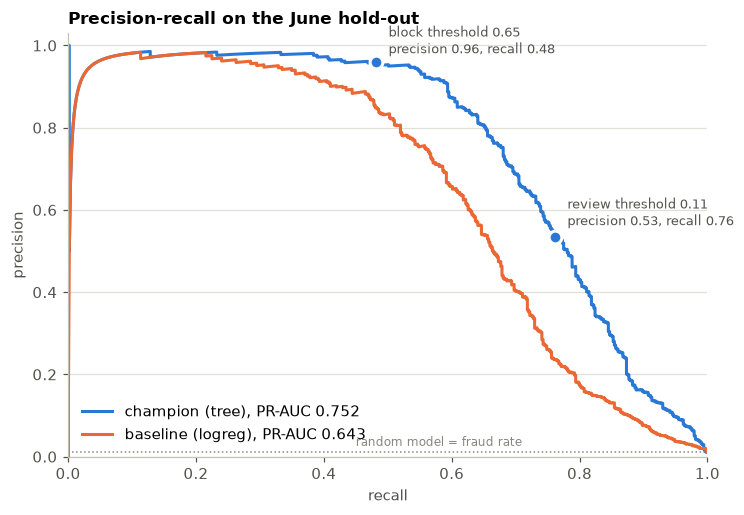

In [21]:
blk_champ = ev.threshold_metrics(y_te, s_te, champion.block_threshold)
blk_base = ev.threshold_metrics(y_te, sb_te, baseline.block_threshold)

fig, ax = plt.subplots(figsize=(7.5, 5))
for s, m, name, colour in ((s_te, m_champ, "champion (tree)", C_MAIN), (sb_te, m_base, "baseline (logreg)", C_ALT)):
    p, r, _ = precision_recall_curve(y_te, s)
    ax.plot(r, p, color=colour, label=f"{name}, PR-AUC {m['pr_auc']:.3f}")
ax.axhline(y_te.mean(), color=C_MUTED, lw=1, ls=":")
ax.annotate("random model = fraud rate", (0.45, y_te.mean()), xytext=(0, 4), textcoords="offset points",
            ha="left", fontsize=8, color=C_MUTED)
for m, label, offset in ((m_champ, "review threshold", (8, 8)), (blk_champ, "block threshold", (8, 6))):
    ax.scatter(m["recall"], m["precision"], s=70, color=C_MAIN, edgecolor="white", linewidth=2, zorder=3)
    ax.annotate(f"{label} {m['threshold']:.2f}\nprecision {m['precision']:.2f}, recall {m['recall']:.2f}",
                (m["recall"], m["precision"]), xytext=offset, textcoords="offset points", fontsize=8.5, color=C_INK)
ax.set(xlabel="recall", ylabel="precision", xlim=(0, 1), ylim=(0, 1.03),
       title="Precision-recall on the June hold-out")
ax.legend(loc="lower left")
savefig("pr_curve_june.png")

The champion's curve lies above the baseline's over the whole useful range. The two marked
points are the champion's thresholds, chosen on May and frozen.

In [22]:
thr_f1 = ev.threshold_for_max_f1(y[masks["valid"]], score[masks["valid"]])     # chosen on May, like the others
points = {
    f"review threshold (precision >= {config.REVIEW_MIN_PRECISION:.2f} on May)": champion.review_threshold,
    "max-F1 threshold (chosen on May)": thr_f1,
    "default 0.5": 0.5,
    f"block threshold (precision >= {config.BLOCK_MIN_PRECISION:.2f} on May)": champion.block_threshold,
}
ops = pd.DataFrame({name: ev.threshold_metrics(y_te, s_te, t) for name, t in points.items()}).T
ops_show = ops[["threshold", "precision", "recall", "f1", "flag_rate", "tp", "fp", "fn"]].astype(
    {"tp": int, "fp": int, "fn": int})
display(fmt(ops_show, {"threshold": ".3f", "precision": ".3f", "recall": ".3f", "f1": ".3f", "flag_rate": ".2%"}))
_d, _f = ops.loc["default 0.5"], ops.loc["max-F1 threshold (chosen on May)"]
_r = ops.iloc[0]
say(f"No single threshold is right. The default 0.5 has no business meaning: it gives precision "
    f"{_d.precision:.2f} but misses {int(_d.fn)} of {int(_d.tp + _d.fn)} frauds. Max-F1 ({_f.threshold:.2f}) has "
    f"the best F1 ({_f.f1:.3f}) yet still declines {int(_f.fp)} genuine customers if used as a hard decline, and "
    f"misses {int(_f.fn)} frauds. The review threshold catches the most fraud (recall {_r.recall:.2f}) but would "
    f"be unacceptable as a decline rule with {int(_r.fp)} false positives. Hence two thresholds and three bands.")

,threshold,precision,recall,f1,flag_rate,tp,fp,fn
review threshold (precision >= 0.50 on May),0.115,0.533,0.762,0.627,1.59%,403,353,126
max-F1 threshold (chosen on May),0.294,0.785,0.656,0.715,0.93%,347,95,182
default 0.5,0.500,0.923,0.565,0.701,0.68%,299,25,230
block threshold (precision >= 0.95 on May),0.652,0.959,0.482,0.642,0.56%,255,11,274


No single threshold is right. The default 0.5 has no business meaning: it gives precision 0.92 but misses 230 of 529 frauds. Max-F1 (0.29) has the best F1 (0.715) yet still declines 95 genuine customers if used as a hard decline, and misses 182 frauds. The review threshold catches the most fraud (recall 0.76) but would be unacceptable as a decline rule with 353 false positives. Hence two thresholds and three bands.

In [23]:
band = pd.Series(champion.decide(s_te), name="band")
bands = pd.DataFrame({"y": y_te, "band": band.to_numpy()}).groupby("band")["y"].agg(
    transactions="size", frauds="sum").loc[["approve", "review", "block"]]
bands["genuine"] = bands.transactions - bands.frauds
bands["share of traffic"] = bands.transactions / bands.transactions.sum()
bands["fraud rate in band"] = bands.frauds / bands.transactions
bands["share of all fraud"] = bands.frauds / bands.frauds.sum()
bands.insert(0, "score range", [f"< {champion.review_threshold:.3f}",
                                f"{champion.review_threshold:.3f} to {champion.block_threshold:.3f}",
                                f">= {champion.block_threshold:.3f}"])
display(fmt(bands, {"transactions": ",", "share of traffic": ".2%", "fraud rate in band": ".1%",
                    "share of all fraud": ".1%"}))
say(f"""
**The policy.** Scores below the review threshold are approved, scores above the block threshold are declined
automatically, and the band in between goes to an analyst.

- **Block** only where the model is nearly certain. The threshold is the lowest score at which precision on
  May was at least {config.BLOCK_MIN_PRECISION:.0%}. On June the band holds {bands.loc['block', 'transactions']}
  payments, of which {bands.loc['block', 'genuine']} are genuine: **{bands.loc['block', 'genuine']} false declines
  in {len(y_te):,} payments** ({bands.loc['block', 'genuine'] / len(y_te):.3%} of traffic), and it stops
  {bands.loc['block', 'share of all fraud']:.0%} of fraud with no human involved. June precision in the band is
  {blk_champ['precision']:.1%}.
- **Review** the uncertain middle: {bands.loc['review', 'transactions']} payments
  ({bands.loc['review', 'share of traffic']:.2%} of traffic, about
  {bands.loc['review', 'transactions'] / (pd.Timestamp(config.TEST_END) - pd.Timestamp(config.TEST_START)).days:.0f}
  per day), of which {bands.loc['review', 'fraud rate in band']:.0%} are fraud. A genuine customer in this band
  gets a check, not a decline.
- **Approve** the rest: {bands.loc['approve', 'share of traffic']:.1%} of traffic with a residual fraud rate of
  {bands.loc['approve', 'fraud rate in band']:.2%}. These {bands.loc['approve', 'frauds']} frauds are the ones
  the model misses.

This serves the goal of few false declines directly: the decline decision is held to a precision floor, and the
recall that a single strict threshold would give up is recovered by the review band at the price of analyst time.
The floors ({config.REVIEW_MIN_PRECISION:.0%} and {config.BLOCK_MIN_PRECISION:.0%}) are policy inputs in
`config.py`; a real team would set them from review capacity and the cost of a false decline.
""")

,score range,transactions,frauds,genuine,share of traffic,fraud rate in band,share of all fraud
band,,,,,,,
approve,< 0.115,"46,828",126,46702,98.41%,0.3%,23.8%
review,0.115 to 0.652,490,148,342,1.03%,30.2%,28.0%
block,>= 0.652,266,255,11,0.56%,95.9%,48.2%



**The policy.** Scores below the review threshold are approved, scores above the block threshold are declined
automatically, and the band in between goes to an analyst.

- **Block** only where the model is nearly certain. The threshold is the lowest score at which precision on
  May was at least 95%. On June the band holds 266
  payments, of which 11 are genuine: **11 false declines
  in 47,584 payments** (0.023% of traffic), and it stops
  48% of fraud with no human involved. June precision in the band is
  95.9%.
- **Review** the uncertain middle: 490 payments
  (1.03% of traffic, about
  21
  per day), of which 30% are fraud. A genuine customer in this band
  gets a check, not a decline.
- **Approve** the rest: 98.4% of traffic with a residual fraud rate of
  0.27%. These 126 frauds are the ones
  the model misses.

This serves the goal of few false declines directly: the decline decision is held to a precision floor, and the
recall that a single strict threshold would give up is recovered by the review band at the price of analyst time.
The floors (50% and 95%) are policy inputs in
`config.py`; a real team would set them from review capacity and the cost of a false decline.


### 3.4 Calibration

Thresholds, the review-queue forecast and the cost view all read the score as a probability,
so it has to behave like one. Class weights inflate raw scores, so a Platt scaling (a logistic
fit on the logit of the raw score) is fitted on May. It is monotone, so ranking metrics are
unchanged.

,raw score,calibrated,Brier change,mean raw score,mean calibrated score,actual fraud rate
May (calibration fitted here),0.00590,0.00441,-25%,0.0195,0.0100,0.0101
June (hold-out),0.00579,0.00461,-20%,0.0201,0.0105,0.0111


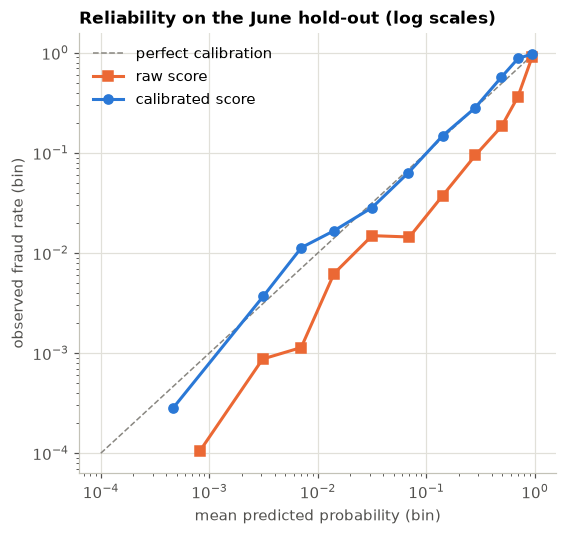

On the hold-out, calibration lowers the Brier score from 0.00579 to 0.00461. The raw score averages 0.020 against an actual fraud rate of 0.011; after calibration the mean is 0.011. In the plot the raw scores sit below the diagonal (they overstate risk) and the calibrated ones are close to it. The top bins hold few transactions, so their positions are noisy.

In [24]:
va = masks["valid"]
raw_all = champion.raw_score(X[va | te])
raw = pd.Series(raw_all, index=np.flatnonzero(va | te))
raw_va, raw_te = raw[np.flatnonzero(va)].to_numpy(), raw[np.flatnonzero(te)].to_numpy()
brier = pd.DataFrame({
    "raw score": [ev.ranking_metrics(y[va], raw_va)["brier"], ev.ranking_metrics(y_te, raw_te)["brier"]],
    "calibrated": [ev.ranking_metrics(y[va], score[va])["brier"], m_champ["brier"]],
    "mean raw score": [raw_va.mean(), raw_te.mean()],
    "mean calibrated score": [score[va].mean(), s_te.mean()],
    "actual fraud rate": [y[va].mean(), y_te.mean()],
}, index=["May (calibration fitted here)", "June (hold-out)"])
brier.insert(2, "Brier change", brier["calibrated"] / brier["raw score"] - 1)
display(fmt(brier, {"raw score": ".5f", "calibrated": ".5f", "Brier change": "+.0%", "mean raw score": ".4f",
                    "mean calibrated score": ".4f", "actual fraud rate": ".4f"}))


def reliability(scores: np.ndarray, edges) -> pd.DataFrame:
    b = pd.cut(scores, edges, include_lowest=True)
    t = pd.DataFrame({"s": scores, "y": y_te, "b": b}).groupby("b", observed=True).agg(
        predicted=("s", "mean"), observed=("y", "mean"), n=("y", "size"))
    return t[t.observed > 0]

edges = [0, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
fig, ax = plt.subplots(figsize=(5.6, 5.2))
ax.plot([1e-4, 1], [1e-4, 1], color=C_MUTED, lw=1, ls="--", label="perfect calibration")
for scores, name, colour, marker in ((raw_te, "raw score", C_ALT, "s"), (s_te, "calibrated score", C_MAIN, "o")):
    t = reliability(scores, edges)
    ax.plot(t.predicted, t.observed, marker=marker, ms=6, color=colour, label=name)
ax.set(xscale="log", yscale="log", xlabel="mean predicted probability (bin)", ylabel="observed fraud rate (bin)",
       title="Reliability on the June hold-out (log scales)")
ax.grid(True, which="major", axis="both")
ax.legend()
savefig("calibration_june.png")
say(f"On the hold-out, calibration lowers the Brier score from {brier['raw score'].iloc[1]:.5f} to "
    f"{brier['calibrated'].iloc[1]:.5f}. The raw score averages {raw_te.mean():.3f} against an actual fraud rate "
    f"of {y_te.mean():.3f}; after calibration the mean is {s_te.mean():.3f}. In the plot the raw scores sit below "
    f"the diagonal (they overstate risk) and the calibrated ones are close to it. The top bins hold few "
    f"transactions, so their positions are noisy.")

### 3.5 Recall by fraud pattern

This breakdown is only possible because the data is synthetic. It is the most useful honesty
check in the notebook: an overall recall hides which fraud is being missed.

In [25]:
pattern_te = df.loc[te, "fraud_pattern"]
by_pattern = ev.recall_by_group(y_te, s_te, pattern_te, champion.review_threshold).set_index("group")
by_pattern["recall, baseline"] = ev.recall_by_group(
    y_te, sb_te, pattern_te, baseline.review_threshold).set_index("group")["recall"]
by_pattern["blocked outright, champion"] = ev.recall_by_group(
    y_te, s_te, pattern_te, champion.block_threshold).set_index("group")["recall"]
by_pattern = by_pattern.rename(columns={"recall": "recall, champion"},
                               index={"genuine": "genuine (label noise)"})
display(fmt(by_pattern, {c: ".1%" for c in by_pattern.columns if c != "frauds"}))
bp = by_pattern["recall, champion"]
say(f"Takeover bursts and mule devices are caught well ({bp['A_takeover']:.0%} and {bp['B_mule']:.0%}): they "
    f"leave strong velocity, new-device and amount traces. **Stealth fraud is the weak spot: recall "
    f"{bp['C_stealth']:.0%}**, so more than half of it is approved. These are single payments at only "
    f"moderately unusual amounts, which the features can barely tell apart from a genuine larger purchase at "
    f"a precision floor of {config.REVIEW_MIN_PRECISION:.0%}. The last row is label noise: genuine payments "
    f"that were disputed. The model is right not to flag them, and they cap the measurable recall slightly.")

,frauds,"recall, champion","recall, baseline","blocked outright, champion"
group,,,,
A_takeover,202,89.6%,74.8%,51.5%
B_mule,173,91.9%,87.3%,80.9%
C_stealth,148,42.6%,23.6%,7.4%
genuine (label noise),6,0.0%,0.0%,0.0%


Takeover bursts and mule devices are caught well (90% and 92%): they leave strong velocity, new-device and amount traces. **Stealth fraud is the weak spot: recall 43%**, so more than half of it is approved. These are single payments at only moderately unusual amounts, which the features can barely tell apart from a genuine larger purchase at a precision floor of 50%. The last row is label noise: genuine payments that were disputed. The model is right not to flag them, and they cap the measurable recall slightly.

### 3.6 Cost and business view

The cost figures are **illustrative assumptions** set in `app/utils/config.py`. They are not
real figures; they make the trade-off between missed fraud, false declines and review effort
visible in one unit.

In [26]:
display(pd.Series({
    "analyst cost per reviewed transaction (INR)": config.REVIEW_COST,
    "false decline: share of the amount lost as margin": config.FALSE_DECLINE_MARGIN,
    "false decline: fixed goodwill / churn cost (INR)": config.FALSE_DECLINE_FIXED,
    "share of reviewed frauds the analyst stops": config.REVIEW_CATCH_RATE,
}).to_frame("assumption"))

biz = pd.DataFrame({
    "no model (approve all)": ev.business_metrics(y_te, np.zeros(len(y_te)), amount_te, 2.0, 2.0),
    "baseline, three bands": ev.business_metrics(y_te, sb_te, amount_te, baseline.review_threshold, baseline.block_threshold),
    "champion, three bands": ev.business_metrics(y_te, s_te, amount_te, champion.review_threshold, champion.block_threshold),
    "champion, single decline threshold 0.5": ev.business_metrics(y_te, s_te, amount_te, 0.5, 0.5),
})
assert np.isclose(biz["champion, three bands"]["total_cost"], training_report["champion"]["test_business"]["total_cost"])
rows = ["approval_rate", "review_queue", "blocked", "false_declines", "fraud_amount_total", "fraud_loss_amount",
        "fraud_value_recall", "total_cost"]
biz_show = biz.loc[rows].T
display(fmt(biz_show, {"approval_rate": ".2%", "review_queue": ",.0f", "blocked": ",.0f", "false_declines": ",.0f",
                       "fraud_amount_total": ",.0f", "fraud_loss_amount": ",.0f", "fraud_value_recall": ".1%",
                       "total_cost": ",.0f"}))
c, b0, single = biz["champion, three bands"], biz["baseline, three bands"], biz["champion, single decline threshold 0.5"]
say(f"Under these assumptions the champion with three bands prevents {c.fraud_value_recall:.0%} of fraud by "
    f"value (recall by count is {m_champ['recall']:.0%}; large frauds are easier to catch), with "
    f"{int(c.false_declines)} false declines and {int(c.review_queue)} reviews in the window. The baseline "
    f"prevents {b0.fraud_value_recall:.0%} with {int(b0.false_declines)} false declines. A single decline "
    f"threshold at 0.5 would need no analysts, but it has {int(single.false_declines)} false declines and loses "
    f"INR {single.fraud_loss_amount - c.fraud_loss_amount:,.0f} more to fraud. The ordering of the options "
    f"depends on the assumed costs; the counts in the table do not.")

,assumption
analyst cost per reviewed transaction (INR),30.00
false decline: share of the amount lost as margin,0.03
false decline: fixed goodwill / churn cost (INR),150.00
share of reviewed frauds the analyst stops,0.90


,approval_rate,review_queue,blocked,false_declines,fraud_amount_total,fraud_loss_amount,fraud_value_recall,total_cost
no model (approve all),100.00%,0,0,0,"10,529,104","10,529,104",0.0%,"10,529,104"
"baseline, three bands",98.78%,360,220,17,"10,529,104","1,673,256",84.1%,"1,695,359"
"champion, three bands",98.41%,490,266,11,"10,529,104","1,036,632",90.2%,"1,060,140"
"champion, single decline threshold 0.5",99.32%,0,324,25,"10,529,104","2,103,195",80.0%,"2,118,057"


Under these assumptions the champion with three bands prevents 90% of fraud by value (recall by count is 76%; large frauds are easier to catch), with 11 false declines and 490 reviews in the window. The baseline prevents 84% with 17 false declines. A single decline threshold at 0.5 would need no analysts, but it has 25 false declines and loses INR 1,066,563 more to fraud. The ordering of the options depends on the assumed costs; the counts in the table do not.

### 3.7 Why a transaction was flagged

Analysts need a reason with each flagged payment. `FraudModel.contributions` replaces one
feature at a time with its typical training value and measures the drop in log-odds.

In [27]:
_i = df.index[te][np.argsort(-s_te)[25]]
display(df.loc[[_i], ["request_time", "service_type", "merchant_type", "mcc_title", "amount"]])
print(f"score {score[_i]:.3f} -> {champion.decide(score[[_i]])[0]}")
display(pd.DataFrame(champion.contributions(X.loc[[_i]])))

,request_time,service_type,merchant_type,mcc_title,amount
297937,2026-06-13 03:10:31,netbanking,medium,Jewelry Stores,21391.08


score 0.988 -> block


,feature,value,typical,log_odds_contribution
0,dev_age_days,0.035046,30.000000,2.294
1,dev_secs_since_last,434.000000,419103.000000,1.547
2,log_amount,9.970776,7.175658,1.230
3,dev_new_service,1.000000,0.000000,1.080
4,dev_amt_sum_24h,148902.380000,0.000000,1.048


One high-scoring June payment with the features that raise its score most. This is an
occlusion method: it ignores interactions between features, so it guides an analyst and is not
an audit trail (section 6).

## 4. Production checks

### 4.1 Input schema, data types, missing values and ranges

`app/controllers/validation/schema.py` runs before scoring and before any retraining. Errors
reject the request or batch; warnings mean the data is usable but something has moved.

In [28]:
display(pd.Series({
    "required columns and types": ", ".join(f"{k}:{v}" for k, v in schema.REQUIRED.items()),
    "must not be null": ", ".join(schema.NOT_NULL),
    "allowed values": "; ".join(f"{k} in {sorted(v)}" for k, v in schema.ALLOWED.items()),
    "amount range": f"{schema.AMOUNT_RANGE[0]} < amount <= {schema.AMOUNT_RANGE[1]:,.0f}",
    "mcc_code range": str(schema.MCC_RANGE),
    "max missing share (batch)": ", ".join(f"{k} {v:.0%}" for k, v in schema.MAX_MISSING.items()),
    "also checked (batch)": "duplicate request_id, time order, fraud_label in {0, 1}",
}).to_frame("rule"))

,rule
required columns and types,"request_id:string, request_time:datetime, service_type:string, device_id:string, merchant_id:string, merchant_state:string, merchant_city:string, merchant_type:string, mcc_code:integer, mcc_title:string, issuer_bank:string, currency_code:string, amount:number, request_status:string"
must not be null,"request_id, request_time, service_type, device_id, merchant_id, merchant_type, mcc_code, amount"
allowed values,"service_type in ['imps', 'netbanking', 'upi', 'wallet']; merchant_type in ['high', 'low', 'medium']; request_status in ['DECLINED', 'FAILED', 'SUCCESS']; currency_code in ['INR']"
amount range,"0.0 < amount <= 10,000,000"
mcc_code range,"(1, 9999)"
max missing share (batch),"issuer_bank 5%, merchant_state 3%, merchant_city 3%, mcc_title 3%, request_status 0%"
also checked (batch),"duplicate request_id, time order, fraud_label in {0, 1}"


In [29]:
good = df[te].drop(columns=["fraud_pattern"]).reset_index(drop=True)


def broken(change) -> pd.DataFrame:
    b = good.copy()
    b["request_time"] = b["request_time"].astype(object)
    change(b)
    return b


def _missing_column(b): b.drop(columns=["merchant_type"], inplace=True)
def _negative_amount(b): b.loc[:2, "amount"] = [-50.0, 0.0, -1.0]
def _bad_timestamp(b): b.loc[5, "request_time"] = "31/02/2026 25:61"
def _text_amount(b):
    b["amount"] = b["amount"].astype(object)
    b.loc[7, "amount"] = "12,000"
def _null_required(b): b.loc[:9, "device_id"] = np.nan
def _unseen_category(b): b.loc[:99, "service_type"] = "card"
def _missing_jump(b): b.loc[b.sample(frac=0.2, random_state=config.SEED).index, "issuer_bank"] = np.nan
def _duplicate_ids(b): b.loc[1, "request_id"] = b.loc[0, "request_id"]

cases = {
    "good batch (June, unmodified)": good,
    "missing column (merchant_type dropped)": broken(_missing_column),
    "negative / zero amount (3 rows)": broken(_negative_amount),
    "unparseable timestamp (1 row)": broken(_bad_timestamp),
    "non-numeric amount (1 row)": broken(_text_amount),
    "null device_id (10 rows)": broken(_null_required),
    "duplicate request_id": broken(_duplicate_ids),
    "unseen category (service_type = 'card', 100 rows)": broken(_unseen_category),
    "missing-rate jump (issuer_bank 20% null)": broken(_missing_jump),
}
results = {name: validate(batch) for name, batch in cases.items()}
display(pd.DataFrame({
    "accepted": {k: r.ok for k, r in results.items()},
    "errors": {k: "; ".join(r.errors) for k, r in results.items()},
    "warnings": {k: "; ".join(r.warnings) for k, r in results.items()},
}))
assert results["good batch (June, unmodified)"].ok and not results["good batch (June, unmodified)"].warnings
assert not any(results[k].ok for k in list(cases)[1:7])
assert all(results[k].ok and results[k].warnings for k in list(cases)[7:])

,accepted,errors,warnings
"good batch (June, unmodified)",True,,
missing column (merchant_type dropped),False,missing columns: ['merchant_type'],
negative / zero amount (3 rows),False,amount: 3 values <= 0,
unparseable timestamp (1 row),False,request_time: 1 unparseable timestamps,
non-numeric amount (1 row),False,amount: 1 non-numeric values,
null device_id (10 rows),False,device_id: 10 missing values in a required field,
duplicate request_id,False,request_id: 1 duplicates,
"unseen category (service_type = 'card', 100 rows)",True,,service_type: unseen values ['card']
missing-rate jump (issuer_bank 20% null),True,,issuer_bank: 20.8% missing (limit 5%)


The clean June batch passes with no findings. Structural problems (missing column, impossible
amount, bad timestamp, wrong type, null key, duplicate ID) are errors and the batch is
rejected. An unseen category and a jump in the missing rate are warnings: the encoders can
handle both, so scoring continues, but they usually mean an upstream change and are surfaced
to monitoring. The September incident in section 5 is caught by exactly this missing-rate check.

Range checks on the engineered features are covered from the other side: the drift monitor in
section 5 compares their distributions with the training window.

### 4.2 Training-serving feature consistency

The usual cause of training-serving skew is two implementations of the features, one in the
training notebook and one in the service. Here there is one: the scoring service
(`app/controllers/scoring/service.py`) calls the same `build_features` on the slice of history
that can influence one transaction (the device's and the merchant's rows from the lookback plus
label-delay window, plus the device's first row, which `dev_age_days` needs). The cell below checks that claim: it takes transactions
from the hold-out and the live period, builds their features the way the service does (history
slice plus the new row, label unknown), and compares with the batch features used for training
and evaluation.

In [30]:
from app.controllers.scoring.service import RAW, ScoringService

service = ScoringService(model=champion, df=df)
rng = np.random.default_rng(config.SEED)
picks = np.sort(rng.choice(np.flatnonzero(te | masks["live"]), 300, replace=False))

max_num_diff, cat_mismatch, max_score_diff = 0.0, 0, 0.0
for i in picks:
    row = df.iloc[[i]][RAW].assign(**{config.TARGET: 0})                 # label unknown at decision time
    hist = service._history(row.device_id.iloc[0], row.merchant_id.iloc[0], row.request_time.iloc[0], int(i))
    online = build_features(pd.concat([hist, row], ignore_index=True)).iloc[[-1]]
    offline = X.iloc[[i]]
    a, b = online[builder.NUMERIC].to_numpy(float)[0], offline[builder.NUMERIC].to_numpy(float)[0]
    assert (np.isnan(a) == np.isnan(b)).all()
    max_num_diff = max(max_num_diff, float(np.nanmax(np.abs(a - b) / (1 + np.abs(b)))))
    cat_mismatch += int((online[builder.CATEGORICAL].fillna("-").to_numpy() !=
                         offline[builder.CATEGORICAL].fillna("-").to_numpy()).sum())
    max_score_diff = max(max_score_diff, abs(float(champion.score(online)[0]) - score[i]))

import re
test_files = {p.relative_to(ROOT).as_posix(): len(re.findall(r"^def test_", p.read_text(), flags=re.M))
              for p in sorted((ROOT / "tests").rglob("test_*.py"))}
parity_tests = sorted({name for p in (ROOT / "tests").rglob("test_*.py")
                       for name in re.findall(r"^def (test_\w*(?:replay|37_days|batch_score)\w*)", p.read_text(), flags=re.M)})
say(f"Over {len(picks)} randomly chosen June-to-September transactions, features built the serving way and the "
    f"batch way agree: largest relative difference in a numeric feature {max_num_diff:.1e}, {cat_mismatch} "
    f"categorical mismatches, same missing-value pattern, largest score difference {max_score_diff:.1e}.")
if test_files:
    display(pd.Series(test_files, name="test functions").to_frame())
    say(f"The same property is covered by the automated suite under `tests/`: {sum(test_files.values())} test "
        f"functions in {len(test_files)} files when this notebook was executed (counted from the source; "
        f"parametrised cases count once, and the suite is not run from this notebook). Tests whose names refer to "
        f"replaying stored rows or rebuilding features from the retained history: "
        + (", ".join(f"`{t}`" for t in parity_tests) or "none found by name") + ".")
else:
    say("No automated tests were found under `tests/` when this notebook was executed; the check above is the "
        "only parity evidence in this run.")

Over 300 randomly chosen June-to-September transactions, features built the serving way and the batch way agree: largest relative difference in a numeric feature 2.4e-09, 0 categorical mismatches, same missing-value pattern, largest score difference 0.0e+00.

,test functions
tests/integration/test_api.py,46
tests/integration/test_pipeline.py,12
tests/unit/test_drift.py,20
tests/unit/test_explanations.py,17
tests/unit/test_features.py,27
tests/unit/test_generator.py,16
tests/unit/test_metrics.py,17
tests/unit/test_model.py,19
tests/unit/test_validation.py,26


The same property is covered by the automated suite under `tests/`: 200 test functions in 9 files when this notebook was executed (counted from the source; parametrised cases count once, and the suite is not run from this notebook). Tests whose names refer to replaying stored rows or rebuilding features from the retained history: `test_features_are_reproducible_from_37_days_of_history`, `test_generated_features_are_reproducible_from_37_days_plus_first_seen_rows`, `test_online_scoring_reproduces_batch_scores_for_the_freshly_trained_model`, `test_replay_matches_batch_scores_across_the_whole_history`, `test_replayed_sample_transactions_get_their_batch_score`, `test_replays_are_idempotent_and_leave_no_trace_in_the_session`, `test_timezone_aware_replay_is_the_same_instant_as_the_stored_gateway_local_time`.

Other controls for consistency: preprocessing (imputation, scaling, encoders) is inside the
saved pipeline and cannot differ between training and serving; the service appends every scored
request with its feature values to a prediction log, which is the input for comparing live
feature distributions with training (section 5).

### 4.3 Model version, evaluation result and rollback plan

In [31]:
card = {
    "model version": model_card["model_version"],
    "trained at": model_card["trained_at"],
    "algorithm": model_card["algorithm"],
    "data": f"{model_card['data']['source']}, seed {model_card['data']['seed']}, {model_card['data']['rows']:,} rows",
    "windows": "; ".join(f"{k} {v[0]} to {v[1]}" for k, v in model_card["windows"].items() if isinstance(v, list)),
    "label delay (days)": model_card["windows"]["label_delay_days"],
    "features": len(model_card["features"]),
    "thresholds": ", ".join(f"{k} {v:.4f}" for k, v in model_card["thresholds"].items()),
    "policy": ", ".join(f"{k} {v}" for k, v in model_card["policy"].items()),
    "release baseline (June)": ", ".join(f"{k} {v:.3f}" for k, v in model_card["release_baseline"].items()),
    "release baseline 95% CI": ", ".join(f"{k} [{v[0]:.3f}, {v[1]:.3f}]" for k, v in model_card["release_baseline_ci95"].items()),
    "rollback": model_card["rollback"],
}
display(pd.Series(card).to_frame("models/model_card.json"))

consistency = pd.Series({
    "artefact version = model card version": champion.version == model_card["model_version"],
    "artefact thresholds = model card thresholds": bool(np.isclose(champion.review_threshold, model_card["thresholds"]["review"])
                                                        and np.isclose(champion.block_threshold, model_card["thresholds"]["block"])),
    "artefact feature list = model card feature list": list(champion.features) == model_card["features"],
    "re-scored June metrics = model card release baseline": all(np.isclose(m_champ[k], v) for k, v in model_card["release_baseline"].items()),
    "champion beats baseline on hold-out PR-AUC": m_champ["pr_auc"] > m_base["pr_auc"],
    f"block-band precision on hold-out >= {config.BLOCK_MIN_PRECISION:.0%}": blk_champ["precision"] >= config.BLOCK_MIN_PRECISION,
    f"review-band precision floor on hold-out >= {config.REVIEW_MIN_PRECISION:.0%}": m_champ["precision"] >= config.REVIEW_MIN_PRECISION,
    "validator accepts the hold-out batch": results["good batch (June, unmodified)"].ok,
    "serving features = training features (sample)": max_num_diff < 1e-6 and cat_mismatch == 0,
}).to_frame("pass")
display(consistency)
assert consistency["pass"].all()

,models/model_card.json
model version,1.0.0
trained at,2026-10-04T16:36:45+00:00
algorithm,gbm | sqrt weights | lr=0.05 trees=300
data,"synthetic (app/controllers/data_generation/generator.py), seed 42, 566,754 rows"
windows,train 2026-01-31 to 2026-05-01; valid 2026-05-08 to 2026-06-01; test 2026-06-08 to 2026-07-01
label delay (days),7
features,33
thresholds,"review 0.1150, block 0.6521"
policy,"review_min_precision 0.5, block_min_precision 0.95"
release baseline (June),"pr_auc 0.752, roc_auc 0.980, precision 0.533, recall 0.762, f1 0.627, false_positive_rate 0.008"


,pass
artefact version = model card version,True
artefact thresholds = model card thresholds,True
artefact feature list = model card feature list,True
re-scored June metrics = model card release baseline,True
champion beats baseline on hold-out PR-AUC,True
block-band precision on hold-out >= 95%,True
review-band precision floor on hold-out >= 50%,True
validator accepts the hold-out batch,True
serving features = training features (sample),True


The model card is written by the training run next to the artefact. The second table is the
release gate, recomputed here: the artefact, the card and the re-scored metrics agree, and the
hold-out meets the policy floors.

**Release and rollback plan.**

1. Before release: the checks above, plus a shadow period in which the new model scores live
   traffic without acting, to compare score distribution and review rate with the current model.
2. The artefact is one versioned file containing pipeline, calibration and thresholds, so a
   release or a rollback is a single file swap; features and thresholds cannot get out of step.
3. Rollback: keep the previous artefact (`fraud_model.prev.joblib`), restore it and restart the
   API. Trigger: a jump in review or block rate right after a release, or a performance alert
   that coincides with a release. A decline that builds up gradually is drift, not a bad release,
   and rolling back does not help (section 5).

## 5. Drift detection and monitoring

The model was built on January to June and now receives July to September. Monitoring is in
four layers, ordered by how early they are available:

| Layer | Needs labels? | Available | Compared with |
|---|---|---|---|
| Data drift (inputs) | no | immediately | the window the model was fitted on |
| Prediction drift (scores) | no | immediately | June hold-out scores |
| Performance drift | yes | after the label delay | June hold-out metrics and their CI |
| Business metrics | partly | approval and queue immediately, losses late | June hold-out |

Scores and metrics are compared with the June hold-out because scores on the training window
itself are optimistic. `monitoring.monitor` computes all four layers per month and maps each
alert to an action; some statistics are also computed directly below to show the method.

In [32]:
rep = monitoring.monitor(df=df, model=champion, save=False)
saved_rep = json.loads((config.REPORTS_DIR / "monitoring_report.json").read_text())
for new, old in zip(rep["months"], saved_rep["months"]):
    for k in ("pr_auc", "precision", "recall", "f1"):
        assert np.isclose(new["performance"][k], old["performance"][k])
    assert np.isclose(new["prediction_drift"]["score_psi"], old["prediction_drift"]["score_psi"])
    assert [a["issue"] for a in new["actions"]] == [a["issue"] for a in old["actions"]]
print("Recomputed monitoring results match reports/monitoring_report.json (metrics, score PSI, actions).")
months = {m["month"]: m for m in rep["months"]}
live_fraud = pd.DataFrame({k: {"transactions": m["rows"], "fraud_rate": m["performance"]["fraud_rate"]}
                           for k, m in months.items()}).T
display(fmt(live_fraud, {"transactions": ",.0f", "fraud_rate": ".2%"}))

Recomputed monitoring results match reports/monitoring_report.json (metrics, score PSI, actions).


,transactions,fraud_rate
2026-07,"67,900",1.22%
2026-08,"75,957",1.76%
2026-09,"87,525",2.18%


Fraud rate by live month, for reference (known only once labels arrive). It rises through the
quarter; the pattern breakdown in section 5.3 shows why.

### 5.1 Data drift

PSI (population stability index) on bins fixed at the reference deciles for numeric features
and on category shares for categorical ones; the KS statistic D for numeric features. With
tens of thousands of rows every KS p-value is 'significant', so the alert uses D, an effect
size, and never the p-value.

In [33]:
ref = df[masks["train"]]
rows = []
for label, start, end in monitoring.LIVE_MONTHS:
    cur = df[window_mask(df, start, end)]
    rows.append({"month": label, "feature": "amount", "PSI": drift.psi_numeric(ref.amount, cur.amount),
                 "KS D": drift.ks_statistic(ref.amount, cur.amount)})
    for col in ("service_type", "merchant_type", "mcc_code", "issuer_bank"):
        rows.append({"month": label, "feature": col, "PSI": drift.psi_categorical(ref[col], cur[col]), "KS D": np.nan})
live_drift = pd.DataFrame(rows)
live_drift["status"] = [
    max(drift.status(p, config.PSI_WARN, config.PSI_ALERT),
        "ok" if np.isnan(k) else drift.status(k, config.KS_WARN, config.KS_ALERT), key=monitoring.ORDER.index)
    for p, k in zip(live_drift.PSI, live_drift["KS D"])]
wide = live_drift.pivot(index="feature", columns="month", values=["PSI", "KS D", "status"]).loc[
    ["amount", "service_type", "merchant_type", "mcc_code", "issuer_bank"]]
display(wide.apply(lambda c: c.map(lambda v: "" if isinstance(v, float) and np.isnan(v) else
                                   (v if isinstance(v, str) else f"{v:.3f}"))))
say(f"Raw inputs against the training window, computed with `drift.psi_numeric`, `drift.psi_categorical` and "
    f"`drift.ks_statistic`. Thresholds: PSI warn {config.PSI_WARN}, alert {config.PSI_ALERT}; KS D warn "
    f"{config.KS_WARN}, alert {config.KS_ALERT}. July is quiet. From August `amount` moves (KS D "
    f"{wide[('KS D', '2026-08')]['amount']:.3f}, then {wide[('KS D', '2026-09')]['amount']:.3f}) and "
    f"`mcc_code` shifts with the sale (PSI {wide[('PSI', '2026-08')]['mcc_code']:.3f}, still under the "
    f"warning level); in September `issuer_bank` jumps to PSI "
    f"{wide[('PSI', '2026-09')]['issuer_bank']:.2f}. Note that `amount` never reaches the PSI warning level: "
    f"a gradual shift of the whole distribution is picked up by KS before PSI on decile bins reacts, which is "
    f"why both are tracked.")

PSI                    KS D                  status                
month         2026-07 2026-08 2026-09 2026-07 2026-08 2026-09 2026-07 2026-08 2026-09
feature                                                                              
amount          0.001   0.062   0.081   0.010   0.091   0.107      ok    warn   alert
service_type    0.002   0.024   0.062                              ok      ok      ok
merchant_type   0.000   0.016   0.017                              ok      ok      ok
mcc_code        0.001   0.088   0.089                              ok      ok      ok
issuer_bank     0.001   0.007   0.233                              ok      ok    warn

Raw inputs against the training window, computed with `drift.psi_numeric`, `drift.psi_categorical` and `drift.ks_statistic`. Thresholds: PSI warn 0.1, alert 0.25; KS D warn 0.05, alert 0.1. July is quiet. From August `amount` moves (KS D 0.091, then 0.107) and `mcc_code` shifts with the sale (PSI 0.088, still under the warning level); in September `issuer_bank` jumps to PSI 0.23. Note that `amount` never reaches the PSI warning level: a gradual shift of the whole distribution is picked up by KS before PSI on decile bins reacts, which is why both are tracked.

In [34]:
all_drift = pd.concat([pd.DataFrame(m["data_drift"]).assign(month=k) for k, m in months.items()])
psi_wide = all_drift.pivot(index="feature", columns="month", values="psi")
status_wide = all_drift.pivot(index="feature", columns="month", values="status")
miss = all_drift.pivot(index="feature", columns="month", values="missing_cur")
order = [d["feature"] for d in rep["months"][0]["data_drift"]]
full = pd.concat({"PSI": psi_wide.round(3), "status": status_wide}, axis=1).loc[order]
full[("missing", "train")] = all_drift.drop_duplicates("feature").set_index("feature").missing_ref.map("{:.1%}".format)
full[("missing", "2026-09")] = miss["2026-09"].map("{:.1%}".format)
display(full)
sep_dq = months["2026-09"]["data_quality"]["warnings"]
say(f"The full monitored set from the monitoring report: six raw inputs and six engineered features. "
    f"Engineered features matter because the model sees those, not the raw columns: in September "
    f"`mer_fraud_rate_lag` and `dev_cnt_24h` are in alert while most raw inputs are not. The September "
    f"`issuer_bank` change is a missing-value problem, not a change in customer mix (missing share "
    f"{full[('missing', 'train')]['issuer_bank']} in training, {full[('missing', '2026-09')]['issuer_bank']} "
    f"in September); the batch validator reports it as: *{'; '.join(sep_dq)}*.")

PSI                  status                 missing        
month              2026-07 2026-08 2026-09 2026-07 2026-08 2026-09   train 2026-09
feature                                                                           
amount               0.001   0.062   0.081      ok    warn   alert    0.0%    0.0%
hour                 0.000   0.022   0.022      ok      ok      ok    0.0%    0.0%
service_type         0.002   0.024   0.062      ok      ok      ok    0.0%    0.0%
merchant_type        0.000   0.016   0.017      ok      ok      ok    0.0%    0.0%
mcc_code             0.001   0.088   0.089      ok      ok      ok    0.0%    0.0%
issuer_bank          0.001   0.007   0.233      ok      ok    warn    0.9%    9.9%
dev_cnt_24h          0.002   0.010   0.060      ok      ok   alert    0.0%    0.0%
dev_logamt_z         0.004   0.019   0.054      ok      ok      ok   39.8%   29.1%
dev_new_merchant     0.001   0.000   0.003      ok      ok      ok    0.0%    0.0%
mer_logamt_z         0.003   0.005   0.008      ok      ok      ok    0.5%    0.1%
mer_fraud_rate_lag   0.008   0.024   0.161      ok      ok   alert    0.0%    0.0%
is_night             0.000   0.032   0.031      ok      ok      ok    0.0%    0.0%

The full monitored set from the monitoring report: six raw inputs and six engineered features. Engineered features matter because the model sees those, not the raw columns: in September `mer_fraud_rate_lag` and `dev_cnt_24h` are in alert while most raw inputs are not. The September `issuer_bank` change is a missing-value problem, not a change in customer mix (missing share 0.9% in training, 9.9% in September); the batch validator reports it as: *issuer_bank: 9.9% missing (limit 5%)*.

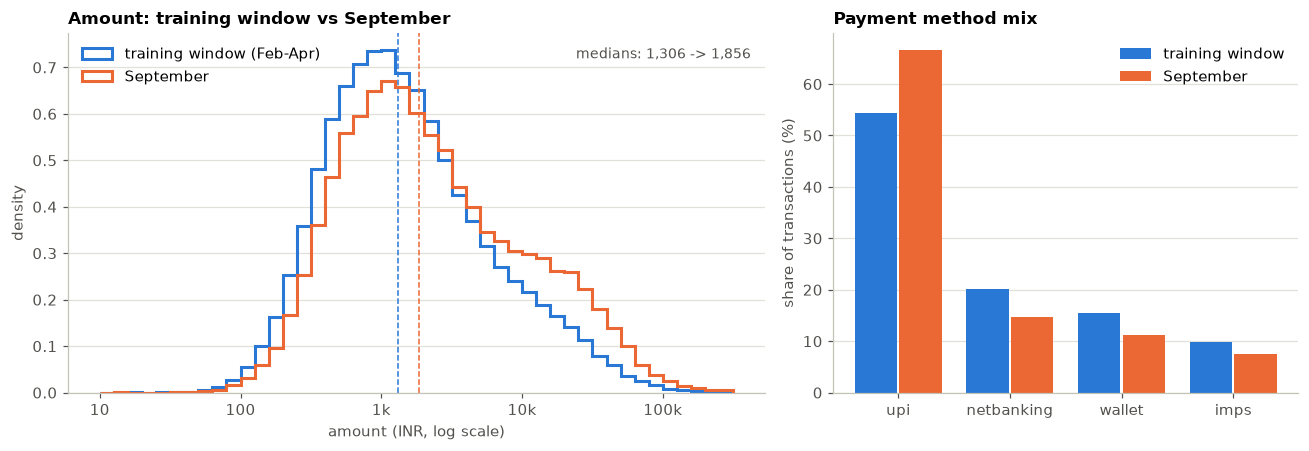

The September amount distribution is shifted to the right of the training one (median INR 1,306 to 1,856, dashed lines) with more mass at high tickets from the sale, and UPI's share grows from 54% to 67%. Both are business changes, not pipeline faults.

In [35]:
sep = df[window_mask(df, "2026-09-01", "2026-10-01")]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.5, 1]})
bins = np.linspace(1, 5.5, 46)
for frame, name, colour in ((ref, "training window (Feb-Apr)", C_MAIN), (sep, "September", C_ALT)):
    ax1.hist(np.log10(frame.amount), bins=bins, density=True, histtype="step", lw=2, color=colour, label=name)
    ax1.axvline(np.log10(frame.amount.median()), color=colour, lw=1, ls="--")
ax1.set_xticks([1, 2, 3, 4, 5], ["10", "100", "1k", "10k", "100k"])
ax1.set(xlabel="amount (INR, log scale)", ylabel="density", title="Amount: training window vs September")
ax1.legend(loc="upper left")
ax1.annotate(f"medians: {ref.amount.median():,.0f} -> {sep.amount.median():,.0f}", (0.98, 0.93),
             xycoords="axes fraction", ha="right", fontsize=9, color=C_INK)
shares = pd.DataFrame({"training window": ref.service_type.value_counts(normalize=True),
                       "September": sep.service_type.value_counts(normalize=True)}).sort_values("training window", ascending=False)
xpos = np.arange(len(shares))
ax2.bar(xpos - 0.2, shares["training window"] * 100, 0.38, color=C_MAIN, label="training window")
ax2.bar(xpos + 0.2, shares["September"] * 100, 0.38, color=C_ALT, label="September")
ax2.set_xticks(xpos, shares.index)
ax2.set(ylabel="share of transactions (%)", title="Payment method mix")
ax2.legend()
fig.tight_layout()
savefig("drift_amount_service.png")
say(f"The September amount distribution is shifted to the right of the training one (median INR "
    f"{ref.amount.median():,.0f} to {sep.amount.median():,.0f}, dashed lines) with more mass at high tickets "
    f"from the sale, and UPI's share grows from {shares.loc['upi', 'training window']:.0%} to "
    f"{shares.loc['upi', 'September']:.0%}. Both are business changes, not pipeline faults.")

### 5.2 Prediction drift

,score PSI vs June,mean score,flag rate (review or block),flag rate vs June,block rate,status,PSI alone would say
June hold-out (baseline),,0.0105,1.59%,,0.56%,,
2026-07,0.000,0.0111,1.64%,+3%,0.62%,ok,ok
2026-08,0.027,0.0121,1.96%,+23%,0.51%,ok,ok
2026-09,0.055,0.0147,2.47%,+56%,0.64%,alert,ok


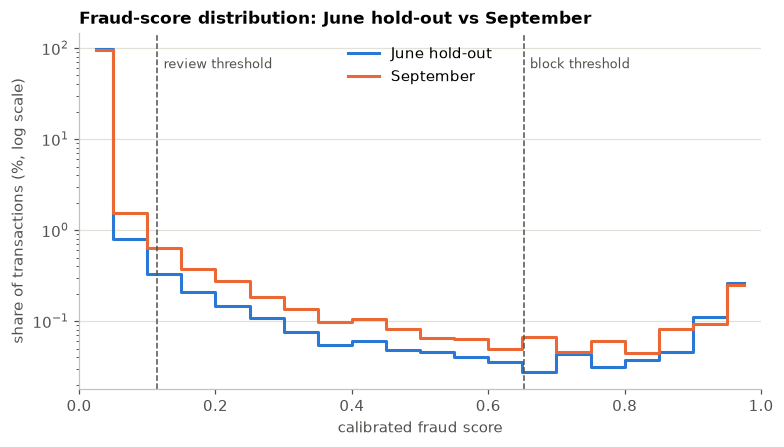

Two label-free signals are tracked. The **score PSI** stays below its warning level of 0.1 in all three months (September 0.055). The **flag rate**, the share of payments at or above the review threshold, grows by 23% in August and 56% in September (warn at 25%, alert at 50% relative change), so the status for September is 'alert'. The histogram shows why they disagree: about 97% of transactions sit in the lowest score bin, so PSI over the whole distribution barely moves when the small tail that drives the review queue grows by half. PSI on a score concentrated near zero is insensitive to the tail, which is why the flagged share is monitored next to it; the status is the worse of the two.

In [36]:
pred = pd.DataFrame({k: m["prediction_drift"] for k, m in months.items()}).T
base_pd = rep["months"][0]["prediction_drift"]
pred_table = pd.DataFrame({
    "score PSI vs June": pred.score_psi, "mean score": pred.mean_score,
    "flag rate (review or block)": pred.flag_rate, "flag rate vs June": pred.flag_rate_change,
    "block rate": pred.block_rate, "status": pred.status})
pred_table.loc["June hold-out (baseline)"] = [np.nan, base_pd["baseline_mean_score"], base_pd["baseline_flag_rate"],
                                              np.nan, base_pd["baseline_block_rate"], ""]
pred_table = pred_table.loc[["June hold-out (baseline)"] + list(months)]
pred_table["PSI alone would say"] = [""] + [drift.status(v, config.PSI_WARN, config.PSI_ALERT) for v in pred.score_psi]
display(fmt(pred_table, {"score PSI vs June": ".3f", "mean score": ".4f", "flag rate (review or block)": ".2%",
                         "block rate": ".2%", "flag rate vs June": "+.0%"}))
# the same statistic, directly:
assert np.isclose(drift.psi_numeric(s_te, score[window_mask(df, "2026-09-01", "2026-10-01").to_numpy()]),
                  months["2026-09"]["prediction_drift"]["score_psi"])

hist = rep["score_histogram"]
centres = (np.array(hist["edges"][:-1]) + np.array(hist["edges"][1:])) / 2
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.step(centres, np.array(hist["baseline_june"]) * 100, where="mid", color=C_MAIN, label="June hold-out")
ax.step(centres, np.array(hist["2026-09"]) * 100, where="mid", color=C_ALT, label="September")
for t, name in ((champion.review_threshold, "review"), (champion.block_threshold, "block")):
    ax.axvline(t, color=C_INK, lw=1, ls="--")
    ax.annotate(f"{name} threshold", (t, 60), xytext=(4, 0), textcoords="offset points", fontsize=8.5, color=C_INK)
ax.set(yscale="log", xlabel="calibrated fraud score", ylabel="share of transactions (%, log scale)",
       title="Fraud-score distribution: June hold-out vs September", xlim=(0, 1))
ax.legend(loc="upper center")
savefig("score_distribution.png")
_s = pred_table.loc["2026-09"]
say(f"Two label-free signals are tracked. The **score PSI** stays below its warning level of {config.PSI_WARN} in "
    f"all three months (September {_s['score PSI vs June']:.3f}). The **flag rate**, the share of payments at or "
    f"above the review threshold, grows by {pred_table.loc['2026-08', 'flag rate vs June']:.0%} in August and "
    f"{_s['flag rate vs June']:.0%} in September (warn at {config.FLAG_RATE_WARN:.0%}, alert at "
    f"{config.FLAG_RATE_ALERT:.0%} relative change), so the status for September is "
    f"'{_s['status']}'. The histogram shows why they disagree: about {hist['baseline_june'][0]:.0%} of "
    f"transactions sit in the lowest score bin, so PSI over the whole distribution barely moves when the "
    f"small tail that drives the review queue grows by half. PSI on a score concentrated near zero is "
    f"insensitive to the tail, which is why the flagged share is monitored next to it; the status is the "
    f"worse of the two.")

### 5.3 Performance drift (once labels arrive)

Labels for a month are complete about a week after it ends, so this layer always lags. Each
month is compared with the June release baseline; a metric below the baseline's bootstrap 95%
interval is a warning, and below 85% of the baseline value an alert.

,pr_auc,roc_auc,precision,recall,f1,labels available from,status (PR-AUC / precision / recall)
June baseline,0.752,0.980,0.533,0.762,0.627,,
June baseline 95% CI,"[0.712, 0.792]","[0.972, 0.986]","[0.497, 0.569]","[0.719, 0.799]","[0.594, 0.658]",,
2026-07,0.700,0.943,0.534,0.719,0.613,2026-08-08,warn / ok / warn
2026-08,0.474,0.862,0.424,0.472,0.447,2026-09-08,alert / alert / alert
2026-09,0.417,0.860,0.383,0.435,0.408,2026-10-08,alert / alert / alert


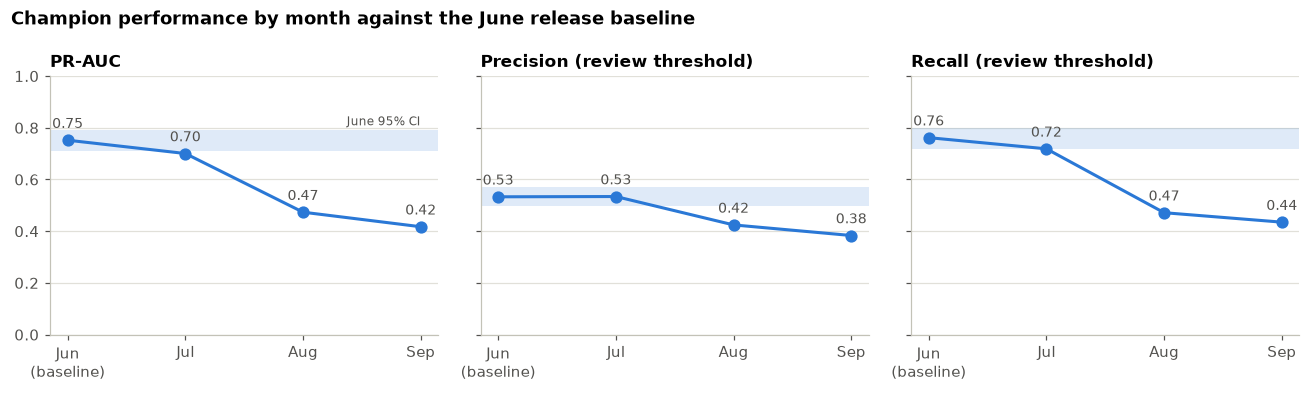

In [37]:
perf_keys = ["pr_auc", "roc_auc", "precision", "recall", "f1"]
perf = pd.DataFrame({k: {**{p: m["performance"][p] for p in perf_keys},
                         "labels available from": m["performance"]["labels_available_from"],
                         "status (PR-AUC / precision / recall)": " / ".join(
                             m["performance"][f"{p}_status"] for p in ("pr_auc", "precision", "recall"))}
                     for k, m in months.items()}).T
base_metrics, base_ci = rep["baseline"]["metrics"], rep["baseline"]["ci95"]
perf.loc["June baseline"] = {**{p: base_metrics[p] for p in perf_keys}, "labels available from": "",
                             "status (PR-AUC / precision / recall)": ""}
perf.loc["June baseline 95% CI"] = {**{p: f"[{base_ci[p][0]:.3f}, {base_ci[p][1]:.3f}]" for p in perf_keys},
                                    "labels available from": "", "status (PR-AUC / precision / recall)": ""}
perf = perf.loc[["June baseline", "June baseline 95% CI"] + list(months)]
display(perf.apply(lambda c: c.map(lambda v: f"{v:.3f}" if isinstance(v, float) else v)))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
labels = ["Jun\n(baseline)", "Jul", "Aug", "Sep"]
for ax, k, title in zip(axes, ("pr_auc", "precision", "recall"), ("PR-AUC", "Precision (review threshold)", "Recall (review threshold)")):
    vals = [base_metrics[k]] + [m["performance"][k] for m in months.values()]
    ax.axhspan(*base_ci[k], color=C_MAIN, alpha=0.15, lw=0)
    ax.plot(labels, vals, marker="o", ms=7, color=C_MAIN)
    for i, v in enumerate(vals):
        ax.annotate(f"{v:.2f}", (i, v), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9, color=C_INK)
    ax.set(title=title, ylim=(0, 1))
axes[0].annotate("June 95% CI", (3, base_ci["pr_auc"][1]), xytext=(0, 3), textcoords="offset points",
                 ha="right", fontsize=8, color=C_INK)
fig.suptitle("Champion performance by month against the June release baseline", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
savefig("performance_drift.png")

In [38]:
pat = pd.concat([pd.DataFrame(m["recall_by_pattern"]).assign(month=k) for k, m in months.items()])
pat_wide = pd.concat({"frauds": pat.pivot(index="group", columns="month", values="frauds"),
                      "recall": pat.pivot(index="group", columns="month", values="recall")}, axis=1)
pat_wide = pat_wide.rename(index={"genuine": "genuine (label noise)"})
display(pat_wide.apply(lambda c: c.map("{:.0f}".format) if c.name[0] == "frauds" else c.map("{:.1%}".format)))
jul, aug, sep_m = (months[k]["performance"] for k in months)

# Where do the extra false positives come from? Genuine payments flagged, June vs September,
# split by the sale categories (generator.PROMO_MCC) and night-time.
from app.controllers.data_generation.generator import PROMO_MCC
sep_mask = window_mask(df, "2026-09-01", "2026-10-01").to_numpy()
segment = np.char.add(np.where(df.mcc_code.isin(list(PROMO_MCC)), "sale categories", "other categories"),
                      np.where(X.is_night == 1, ", night", ", day"))
fp_rows = {}
for name, mask in (("June", te), ("September", sep_mask)):
    g = pd.DataFrame({"segment": segment[mask & (y == 0)], "flagged": (score >= champion.review_threshold)[mask & (y == 0)]})
    t = g.groupby("segment").flagged.agg(["size", "sum", "mean"])
    fp_rows[(name, "genuine payments")], fp_rows[(name, "flagged")], fp_rows[(name, "flag rate")] = t["size"], t["sum"], t["mean"]
fp_table = pd.DataFrame(fp_rows)
fp_table[("September", "share of false positives")] = fp_table[("September", "flagged")] / fp_table[("September", "flagged")].sum()
display(fp_table.apply(lambda c: c.map("{:.2%}".format) if c.name[1] in ("flag rate", "share of false positives") else c.map("{:,.0f}".format)))
sale_night, other_day = fp_table.loc["sale categories, night"], fp_table.loc["other categories, day"]
abc_june = by_pattern.loc[["A_takeover", "B_mule", "C_stealth"]]
d_sep = pat[(pat.group == "D_upi_scam") & (pat.month == "2026-09")].iloc[0]
abc = pat[pat.group.isin(["A_takeover", "B_mule", "C_stealth"]) & (pat.month == "2026-09")]
say(f"""
- **July:** PR-AUC {jul['pr_auc']:.3f} and recall {jul['recall']:.3f} fall just below the June interval (a
  warning); precision is unchanged. The cause is already visible in the pattern table: the first
  {int(pat[(pat.group == 'D_upi_scam') & (pat.month == '2026-07')].frauds.iloc[0])} cases of a new pattern.
- **August and September:** PR-AUC falls to {aug['pr_auc']:.3f} and {sep_m['pr_auc']:.3f}, recall to
  {aug['recall']:.3f} and {sep_m['recall']:.3f}, precision to {aug['precision']:.3f} and {sep_m['precision']:.3f}.
  All far outside the June interval.
- **Why recall falls.** Recall on the three patterns the model was trained on is about the same in September
  ({(abc.frauds * abc.recall).sum() / abc.frauds.sum():.0%} combined) as in June
  ({(abc_june.frauds * abc_june['recall, champion']).sum() / abc_june.frauds.sum():.0%}). The loss comes from
  the new UPI scam pattern: {int(d_sep.frauds)} frauds in September, of which the model catches
  {d_sep.recall:.0%}. That is concept drift, a kind of fraud that did not exist in the training data.
- **Why precision falls** (second table). Night-time purchases in the sale categories grow from
  {sale_night[('June', 'genuine payments')]:,.0f} genuine payments in the June window to
  {sale_night[('September', 'genuine payments')]:,.0f} in September and are flagged
  {sale_night[('September', 'flag rate')]:.1%} of the time; they are
  {sale_night[('September', 'share of false positives')]:.0%} of September's false positives. The larger part
  is a general rise on ordinary daytime traffic, from {other_day[('June', 'flag rate')]:.2%} to
  {other_day[('September', 'flag rate')]:.2%} flagged
  ({other_day[('September', 'share of false positives')]:.0%} of false positives). That is consistent with the
  drift in amounts and in the engineered features (section 5.1), but it is not broken down further here.
- **What the label-free layers saw.** Input drift and the rising review rate gave an early signal for the
  precision problem. Nothing label-free flagged the recall problem: small UPI payments at low-risk merchants
  look like ordinary traffic. A new fraud pattern is only detected when labels arrive, which is the argument
  for getting labels fast (chargeback feeds, analyst decisions) and for sampling approved traffic for review.
""")

frauds                  recall                
month                 2026-07 2026-08 2026-09 2026-07 2026-08 2026-09
group                                                                
A_takeover                346     360     416   93.9%   90.0%   86.1%
B_mule                    191     150     247   96.3%   91.3%   94.7%
C_stealth                 169     233     234   45.0%   48.5%   47.0%
D_upi_scam                 99     569     981   10.1%   10.0%   12.9%
genuine (label noise)      23      26      30    0.0%    0.0%    3.3%

June                          September                                           
                        genuine payments flagged flag rate genuine payments flagged flag rate share of false positives
segment                                                                                                               
other categories, day             41,574     286     0.69%           67,740     829     1.22%                   62.10%
other categories, night            2,288      49     2.14%            4,034     129     3.20%                    9.66%
sale categories, day               3,040      15     0.49%            9,038     117     1.29%                    8.76%
sale categories, night               153       3     1.96%            4,805     260     5.41%                   19.48%


- **July:** PR-AUC 0.700 and recall 0.719 fall just below the June interval (a
  warning); precision is unchanged. The cause is already visible in the pattern table: the first
  99 cases of a new pattern.
- **August and September:** PR-AUC falls to 0.474 and 0.417, recall to
  0.472 and 0.435, precision to 0.424 and 0.383.
  All far outside the June interval.
- **Why recall falls.** Recall on the three patterns the model was trained on is about the same in September
  (78% combined) as in June
  (77%). The loss comes from
  the new UPI scam pattern: 981 frauds in September, of which the model catches
  13%. That is concept drift, a kind of fraud that did not exist in the training data.
- **Why precision falls** (second table). Night-time purchases in the sale categories grow from
  153 genuine payments in the June window to
  4,805 in September and are flagged
  5.4% of the time; they are
  19% of September's false positives. The larger part
  is a general rise on ordinary daytime traffic, from 0.69% to
  1.22% flagged
  (62% of false positives). That is consistent with the
  drift in amounts and in the engineered features (section 5.1), but it is not broken down further here.
- **What the label-free layers saw.** Input drift and the rising review rate gave an early signal for the
  precision problem. Nothing label-free flagged the recall problem: small UPI payments at low-risk merchants
  look like ordinary traffic. A new fraud pattern is only detected when labels arrive, which is the argument
  for getting labels fast (chargeback feeds, analyst decisions) and for sampling approved traffic for review.


### 5.4 Business metrics

In [39]:
def biz_row(b: dict, days: int) -> dict:
    return {"transactions": b["transactions"], "approval rate": b["approval_rate"],
            "reviews per day": b["review_queue"] / days, "false declines": b["false_declines"],
            "false declines per 10k": 1e4 * b["false_declines"] / b["transactions"],
            "fraud amount (INR)": b["fraud_amount_total"], "fraud loss (INR)": b["fraud_loss_amount"],
            "fraud prevented by value": b["fraud_value_recall"], "total cost (INR)": b["total_cost"]}

june_days = (pd.Timestamp(config.TEST_END) - pd.Timestamp(config.TEST_START)).days
business = pd.DataFrame({"June hold-out (baseline)": biz_row(rep["baseline"]["business"], june_days)})
for label, start, end in monitoring.LIVE_MONTHS:
    business[label] = biz_row(months[label]["business"], (pd.Timestamp(end) - pd.Timestamp(start)).days)
business = business.T
business["loss per 10k transactions (INR)"] = 1e4 * business["fraud loss (INR)"] / business.transactions
display(fmt(business, {"transactions": ",.0f", "approval rate": ".2%", "reviews per day": ".0f",
                       "false declines": ".0f", "false declines per 10k": ".1f", "fraud amount (INR)": ",.0f",
                       "fraud loss (INR)": ",.0f", "fraud prevented by value": ".1%", "total cost (INR)": ",.0f",
                       "loss per 10k transactions (INR)": ",.0f"}))
b0, b9 = business.iloc[0], business.loc["2026-09"]
say(f"Per-day and per-10k columns make windows of different length comparable (the June hold-out is "
    f"{june_days} days). By September the review queue has grown from {b0['reviews per day']:.0f} to "
    f"{b9['reviews per day']:.0f} per day, false declines from {b0['false declines per 10k']:.1f} to "
    f"{b9['false declines per 10k']:.1f} per 10,000 payments, and the fraud loss per 10,000 payments from INR "
    f"{b0['loss per 10k transactions (INR)']:,.0f} to {b9['loss per 10k transactions (INR)']:,.0f}. The "
    f"approval rate moves by under a percentage point ({b0['approval rate']:.2%} to {b9['approval rate']:.2%}), "
    f"so on its own it would not raise an alarm. Approval rate, queue size and block count are available "
    f"the same day; fraud loss and false declines need labels. Cost figures use the illustrative "
    f"assumptions from section 3.6.")

,transactions,approval rate,reviews per day,false declines,false declines per 10k,fraud amount (INR),fraud loss (INR),fraud prevented by value,total cost (INR),loss per 10k transactions (INR)
June hold-out (baseline),"47,584",98.41%,21,11,2.3,"10,529,104","1,036,632",90.2%,"1,060,140","217,853"
2026-07,"67,900",98.36%,22,30,4.4,"15,042,152","1,323,573",91.2%,"1,367,493","194,930"
2026-08,"75,957",98.04%,35,23,3.0,"17,001,891","3,309,969",80.5%,"3,366,993","435,769"
2026-09,"87,525",97.53%,53,80,9.1,"21,970,190","4,402,400",80.0%,"4,519,210","502,988"


Per-day and per-10k columns make windows of different length comparable (the June hold-out is 23 days). By September the review queue has grown from 21 to 53 per day, false declines from 2.3 to 9.1 per 10,000 payments, and the fraud loss per 10,000 payments from INR 217,853 to 502,988. The approval rate moves by under a percentage point (98.41% to 97.53%), so on its own it would not raise an alarm. Approval rate, queue size and block count are available the same day; fraud loss and false declines need labels. Cost figures use the illustrative assumptions from section 3.6.

### 5.5 Alerts and actions

Each alert maps to one action in the runbook. The table is produced by the monitoring report
for each month.

In [40]:
actions = pd.DataFrame([{"month": k, "month status": m["status"], **a} for k, m in months.items() for a in m["actions"]])
display(actions)

,month,month status,severity,issue,action
0,2026-07,warn,warn,"Recall 0.72 vs 0.76, PR-AUC 0.70 vs 0.75 (fraud being missed)","Train a challenger on recent data, run it in shadow mode against the champion, and promote it if it wins at the same alert rate. Retrain on a fixed schedule afterwards."
1,2026-08,alert,warn,"Input drift: amount (PSI 0.06, KS 0.09)","Confirm it is a real business change (pricing, promotion, product mix) and not a pipeline fault; if real, check prediction drift and schedule a challenger trained on recent data."
2,2026-08,alert,alert,Precision 0.42 vs baseline 0.53 (more false positives),Re-tune the decision thresholds on the most recent labelled window to restore the precision floor.
3,2026-08,alert,alert,"Recall 0.47 vs 0.76, PR-AUC 0.47 vs 0.75 (fraud being missed)","Train a challenger on recent data, run it in shadow mode against the champion, and promote it if it wins at the same alert rate. Retrain on a fixed schedule afterwards."
4,2026-09,alert,warn,Data quality: issuer_bank: 9.9% missing (limit 5%),Investigate data quality with the upstream owner before trusting scores; do not retrain on the affected rows until fixed.
5,2026-09,alert,alert,"Input drift: amount (PSI 0.08, KS 0.11), issuer_bank (PSI 0.23), dev_cnt_24h (PSI 0.06, KS 0.11), mer_fraud_rate_lag (PSI 0.16, KS 0.18)","Confirm it is a real business change (pricing, promotion, product mix) and not a pipeline fault; if real, check prediction drift and schedule a challenger trained on recent data."
6,2026-09,alert,alert,Prediction drift: 2.47% of payments flagged for review or block vs 1.59% at release (+56%); score PSI 0.06,"Adjust the decision thresholds to keep the review queue within analyst capacity, then confirm with labels once they arrive."
7,2026-09,alert,alert,Precision 0.38 vs baseline 0.53 (more false positives),Re-tune the decision thresholds on the most recent labelled window to restore the precision floor.
8,2026-09,alert,alert,"Recall 0.44 vs 0.76, PR-AUC 0.42 vs 0.75 (fraud being missed)","Train a challenger on recent data, run it in shadow mode against the champion, and promote it if it wins at the same alert rate. Retrain on a fixed schedule afterwards."
9,2026-09,alert,alert,Severe performance collapse (PR-AUC below 60% of the release baseline),"If this followed a model or pipeline release, roll back to the previous version. If it built up gradually (a new fraud pattern), add a temporary rule for the pattern and fast-track the challenger."


The same mapping as a general runbook:

| Signal | First question | Action |
|---|---|---|
| Validation errors, missing-rate jump, unseen categories | Is the data wrong? | **Investigate data quality** with the upstream owner; do not retrain on the affected rows |
| Input drift with stable data quality | Real business change or pipeline fault? | If real: watch the review rate, schedule a **challenger** on recent data |
| Review or block rate moves, labels not yet in | Can analysts absorb the queue? | **Adjust the decision threshold** to hold the queue; confirm with labels later |
| Precision below baseline | More false positives | **Re-tune thresholds** on the latest labelled window |
| Recall or PR-AUC below baseline | Fraud is being missed; thresholds cannot fix ranking | **Train a challenger**, run it in **shadow**, promote if it wins; then **retrain** on a schedule |
| Sudden change right after a release | Is the release at fault? | **Roll back** to the previous artefact |
| Gradual collapse (new fraud pattern) | Rollback does not help | Temporary rule for the pattern, fast-track the challenger |

### 5.6 September remediation: what the actions achieve

By 8 September, labels up to the end of August exist. Using only data available at that time,
three options are compared on 8 to 30 September traffic: the champion unchanged; the champion
with thresholds re-tuned on August; and a challenger trained on data up to the end of July (January
again warm-up only), calibrated and thresholded on August, scoring in shadow.

In [41]:
rem = pd.DataFrame(rep["remediation"]["rows"]).set_index("model")
assert np.allclose(rem.pr_auc, [r["pr_auc"] for r in saved_rep["remediation"]["rows"]])
rem_show = rem[["pr_auc", "roc_auc", "precision", "recall", "f1", "review_threshold", "block_threshold",
                "fp", "fn", "false_declines", "review_queue", "fraud_loss_amount", "total_cost"]]
display(fmt(rem_show, {"pr_auc": ".3f", "roc_auc": ".3f", "precision": ".3f", "recall": ".3f", "f1": ".3f",
                       "review_threshold": ".3f", "block_threshold": ".3f", "fraud_loss_amount": ",.0f",
                       "total_cost": ",.0f"}))
r0, r1, r2 = (rem.iloc[i] for i in range(3))
say(f"""
**Reading it honestly** (window {rep['remediation']['window'][0]} to {rep['remediation']['window'][1]}):

- **Re-tuning thresholds** does what it is meant to: false positives fall from {int(r0.fp)} to {int(r1.fp)},
  false declines from {int(r0.false_declines)} to {int(r1.false_declines)}, the review queue from
  {int(r0.review_queue)} to {int(r1.review_queue)}, and precision rises from {r0.precision:.2f} to
  {r1.precision:.2f}. It cannot improve ranking (PR-AUC is identical by construction) and it costs recall
  ({r0.recall:.2f} to {r1.recall:.2f}): the fraud loss goes **up** by INR
  {r1.fraud_loss_amount - r0.fraud_loss_amount:,.0f} and so does the total cost under the illustrative
  assumptions. Even after re-tuning, precision stays below the {config.REVIEW_MIN_PRECISION:.0%} floor the
  thresholds were tuned for on August, because September differs from August again.
- **The challenger** is better than the champion but only partly recovers: PR-AUC {r2.pr_auc:.3f} against
  {r0.pr_auc:.3f}, where the June release baseline was {base_metrics['pr_auc']:.3f}. It has the highest
  precision ({r2.precision:.2f}) and the fewest false declines ({int(r2.false_declines)}), with recall
  ({r2.recall:.2f}) about the same as the unchanged champion ({r0.recall:.2f}). Its fraud loss is INR
  {abs(r2.fraud_loss_amount - r0.fraud_loss_amount):,.0f}
  {'higher' if r2.fraud_loss_amount > r0.fraud_loss_amount else 'lower'} than the unchanged champion's,
  so on total cost it is {'not ahead' if r2.total_cost > r0.total_cost else 'ahead'}.
- **Why the recovery is partial.** The challenger's training data contains the new pattern only for the three
  weeks of July in which it was still rare
  ({int(pat[(pat.group == 'D_upi_scam') & (pat.month == '2026-07')].frauds.iloc[0])} frauds), while September
  has {int(d_sep.frauds)}. One more month of labels would help, and so would features aimed at the pattern
  (payee novelty across devices, clusters of identical price points). A retrain on the same features is not
  a cure.
- **Caveat on the comparison.** The three rows use different thresholds and therefore different alert
  volumes; PR-AUC and ROC-AUC are the like-for-like columns. A promotion decision would compare champion and
  challenger at the same review volume over a longer shadow period.

**None of the three options is a clear win, and none comes close to the release baseline.** The challenger
ranks better and declines fewer genuine customers; the unchanged champion loses the least money under the
assumed costs because its lower thresholds catch more. On this evidence the sensible sequence is: keep the
challenger in shadow and compare it with the champion at equal review volume; put a temporary rule on the new
pattern meanwhile; and treat new features plus more labelled examples of the pattern as the actual fix.
""")

,pr_auc,roc_auc,precision,recall,f1,review_threshold,block_threshold,fp,fn,false_declines,review_queue,fraud_loss_amount,total_cost
model,,,,,,,,,,,,,
champion v1.0.0 (unchanged),0.404,0.858,0.371,0.428,0.398,0.115,0.652,1095,865,59,1321,"3,469,958","3,561,011"
"champion v1.0.0, thresholds re-tuned on August",0.404,0.858,0.433,0.396,0.414,0.160,0.714,783,913,43,1012,"3,986,686","4,056,010"
"challenger v1.1.0 (trained to end of July, shadow)",0.443,0.889,0.456,0.433,0.444,0.191,0.632,780,858,41,1032,"3,566,909","3,624,921"



**Reading it honestly** (window 2026-09-08 to 2026-10-01):

- **Re-tuning thresholds** does what it is meant to: false positives fall from 1095 to 783,
  false declines from 59 to 43, the review queue from
  1321 to 1012, and precision rises from 0.37 to
  0.43. It cannot improve ranking (PR-AUC is identical by construction) and it costs recall
  (0.43 to 0.40): the fraud loss goes **up** by INR
  516,728 and so does the total cost under the illustrative
  assumptions. Even after re-tuning, precision stays below the 50% floor the
  thresholds were tuned for on August, because September differs from August again.
- **The challenger** is better than the champion but only partly recovers: PR-AUC 0.443 against
  0.404, where the June release baseline was 0.752. It has the highest
  precision (0.46) and the fewest false declines (41), with recall
  (0.43) about the same as the unchanged champion (0.43). Its fraud loss is INR
  96,951
  higher than the unchanged champion's,
  so on total cost it is not ahead.
- **Why the recovery is partial.** The challenger's training data contains the new pattern only for the three
  weeks of July in which it was still rare
  (99 frauds), while September
  has 981. One more month of labels would help, and so would features aimed at the pattern
  (payee novelty across devices, clusters of identical price points). A retrain on the same features is not
  a cure.
- **Caveat on the comparison.** The three rows use different thresholds and therefore different alert
  volumes; PR-AUC and ROC-AUC are the like-for-like columns. A promotion decision would compare champion and
  challenger at the same review volume over a longer shadow period.

**None of the three options is a clear win, and none comes close to the release baseline.** The challenger
ranks better and declines fewer genuine customers; the unchanged champion loses the least money under the
assumed costs because its lower thresholds catch more. On this evidence the sensible sequence is: keep the
challenger in shadow and compare it with the champion at equal review volume; put a temporary rule on the new
pattern meanwhile; and treat new features plus more labelled examples of the pattern as the actual fix.


## 6. Limitations and next steps

**Limitations**

- **Synthetic data.** The fraud patterns were written by the same person who built the features, so the
  features fit the patterns better than they would fit real fraud. The metrics measure recovery of simulated
  patterns. The parts expected to transfer are the method and the checks, not the numbers.
- **Selective labels.** In production a blocked payment never completes, so it never gets a fraud label, and
  a reviewed payment gets the analyst's decision rather than the truth. Here every row has a label. Real
  monitoring of precision in the block band needs a small randomly approved control group, or it measures
  nothing; retraining only on approved traffic biases the next model.
- **Label delay** is modelled as a fixed 7 days. Real chargebacks arrive over weeks to months with a long
  tail, so recent months are under-labelled and the performance layer lags further than shown.
- **Stealth fraud** is mostly missed (section 3.5), and the new pattern almost entirely (section 5.3). Both
  need new information (payee or beneficiary history, device fingerprint, network features), not more tuning.
- **Label-free monitoring cannot see a new fraud pattern.** The flag-rate alert reacts to the growing review
  queue (section 5.2) and the score PSI does not, but neither says anything about fraud that scores low. The
  flag-rate thresholds are, like the PSI ones, rule-of-thumb values.
- **PSI and KS cut-offs are conventions**, not tests. They depend on bin count and sample size and should be
  tuned against the normal month-to-month variation of each feature.
- **Explanations are occlusion-based**: one feature at a time against a typical value. They ignore
  interactions and can understate features that only matter in combination.
- **Small model search.** Eleven candidates on one validation window, no hyper-parameter search beyond that
  grid, and differences between the tree variants within noise (section 2.4). The thresholds come from a
  single month with a few hundred frauds.
- **Cost figures are illustrative**, so conclusions that depend on them (which option is cheapest) are
  provisional; counts and rates are not affected.
- **Serving** keeps feature history in memory. Production needs an online feature store with about 37 days of
  retention (30-day lookback plus label delay) and the parity check of section 4.2 as an automated test.

**Next steps**

1. Prequential (rolling-origin) validation: train to month *m*, test on month *m+1*, repeat. This gives a
   distribution of performance instead of one June number and shows how fast the model ages, which sets the
   retraining interval.
2. Bootstrap intervals for the monthly live metrics, and alert thresholds tuned on normal month-to-month variation.
3. A control group of randomly approved traffic to measure block-band precision without selection bias.
4. Features for the new pattern, then a challenger in shadow compared at equal review volume.
5. Hyper-parameter search with the same time-based protocol; SHAP-style attributions if explanations are
   used for anything beyond analyst guidance.

In [42]:
print(f"Notebook executed in {time.time() - _t0:.0f} s. Figures saved to {config.FIGURES_DIR.relative_to(ROOT)}/: "
      + ", ".join(sorted(p.name for p in config.FIGURES_DIR.glob('*.png'))))

Notebook executed in 38 s. Figures saved to reports/figures/: calibration_june.png, drift_amount_service.png, eda_fraud_signals.png, performance_drift.png, pr_curve_june.png, score_distribution.png
